In [2]:
import pybamm
import numpy as np

# =====================================================
# JOKAR CATHODE OCP
# =====================================================

aa = 0.5

cath_soc = (1-aa) + aa*(1-np.array([
    1.000000000,0.998466258,0.990797546,0.980061350,
    0.975460123,0.967791411,0.957055215,0.946319018,
    0.924846626,0.900306748,0.866564417,0.829754601,
    0.786809816,0.737730061,0.627300613,0.565950920,
    0.493865031,0.434049080,0.394171779,0.328220859,
    0.256134969,0.202453988,0.182515337,0.156441718,
    0.133435583,0.108895706,0.088957055,0.076687117,
    0.062883436,0.056748466,0.049079755,0.039877301,
    0.032208589,0.026073620,0.021472393,0.015337423,
    0.012269939,0.009202454,0.007668712,0.003067485,
    0.003067480,0.001533742,0.001533741,0.001533740
]))

cath_ocv = np.array([
    3.597674419,3.552330932,3.465148381,3.402395135,
    3.391946069,3.381507704,3.371080040,3.360652376,
    3.353750535,3.350347767,3.346977101,3.340128763,
    3.336790198,3.329984663,3.312928021,3.309653660,
    3.302928378,3.296160294,3.289322657,3.282575974,
    3.268873948,3.251619347,3.241223784,3.230849622,
    3.220464760,3.210085248,3.196201313,3.175313882,
    3.136989942,3.112592738,3.081224140,3.039395777,
    2.997562063,2.948746255,2.906901840,2.830179056,
    2.774375803,2.718572550,2.662763946,2.582547439,
    2.519756741,2.449994650,2.380227208,2.334878371
])

# same OCP shift as your calibrated model
cath_ocv = cath_ocv + 0.17

idx = np.argsort(cath_soc)

cath_soc = cath_soc[idx]
cath_ocv = cath_ocv[idx]

mask = np.concatenate(([True], np.diff(cath_soc) > 1e-6))

cath_soc = cath_soc[mask]
cath_ocv = cath_ocv[mask]

sto_grid = np.linspace(0, 1, 1000)

ocv_grid = np.interp(
    sto_grid,
    cath_soc,
    cath_ocv,
    left=cath_ocv[0],
    right=cath_ocv[-1]
)

def custom_positive_ocp(sto):

    return pybamm.Interpolant(
        sto_grid,
        ocv_grid,
        sto
    )

In [6]:
import pybamm
import numpy as np
from scipy.optimize import differential_evolution
from scipy.io import loadmat

# =====================================================
# MEASURED DATA
# =====================================================

data = loadmat(
    "Discharge_1C_8762.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = data["meas"]

time_exp = np.asarray(
    meas.Time,
    dtype=float
)

voltage_exp = np.asarray(
    meas.Voltage,
    dtype=float
)

time_exp = time_exp - time_exp[0]

t_compare = 3550

mask = time_exp <= t_compare

time_exp = time_exp[mask]
voltage_exp = voltage_exp[mask]

# =====================================================
# BASE PARAMETERS
# =====================================================

params_base = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params_base[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params_base[
    "Maximum concentration in positive electrode [mol.m-3]"
]

params_base.update({

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Negative electrode thickness [m]":
        129e-6,

    "Positive electrode thickness [m]":
        171e-6,

    "Positive electrode active material volume fraction":
        0.55,

    "Positive particle radius [m]":
        2.5e-6,

    "Positive electrode diffusivity [m2.s-1]":
        5.9e-15,

    "Current function [A]":
        2.5,

    "Contact resistance [Ohm]":
        0.008,
})

# =====================================================
# FAST MODEL
# =====================================================

model = pybamm.lithium_ion.SPMe()

solver = pybamm.CasadiSolver(
    mode="fast"
)

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(x):

    theta_n_init = x[0]
    theta_p_init = x[1]

    try:

        params = params_base.copy()

        params.update({

            "Initial concentration in negative electrode [mol.m-3]":
                theta_n_init * c_n_max,

            "Initial concentration in positive electrode [mol.m-3]":
                theta_p_init * c_p_max,

        })

        sim = pybamm.Simulation(
            model,
            parameter_values=params,
            solver=solver
        )

        sol = sim.solve(
            np.linspace(
                0,
                t_compare,
                120
            )
        )

        time_model = sol[
            "Time [s]"
        ].entries

        voltage_model = sol[
            "Terminal voltage [V]"
        ].entries

        voltage_interp = np.interp(
            time_exp,
            time_model,
            voltage_model
        )

        rmse = np.sqrt(
            np.mean(
                (
                    voltage_exp -
                    voltage_interp
                ) ** 2
            )
        )

        return rmse

    except Exception:

        return 1e6

# =====================================================
# LOCAL SEARCH BOUNDS
# =====================================================

bounds = [

    (0.905, 0.925),   # theta_n_init

    (0.500, 0.515),   # theta_p_init

]

# =====================================================
# OPTIMIZATION
# =====================================================

result = differential_evolution(

    objective,

    bounds,

    seed=42,

    maxiter=15,

    popsize=8,

    polish=True,

    disp=True
)

# =====================================================
# RESULTS
# =====================================================

theta_n_best = result.x[0]
theta_p_best = result.x[1]

print("\n========================")
print("OPTIMUM PARAMETERS")
print("========================")

print("theta_n_init =", theta_n_best)
print("theta_p_init =", theta_p_best)
print("RMSE =", result.fun)

differential_evolution step 1: f(x)= 0.1933483499229955
Polishing solution with 'L-BFGS-B'

OPTIMUM PARAMETERS
theta_n_init = 0.905
theta_p_init = 0.5
RMSE = 0.19260365148148015


In [7]:
import pybamm
import numpy as np
from scipy.io import loadmat

# =====================================================
# MEASURED DATA
# =====================================================

data = loadmat(
    "Discharge_1C_8762.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = data["meas"]

time_exp = np.asarray(
    meas.Time,
    dtype=float
)

voltage_exp = np.asarray(
    meas.Voltage,
    dtype=float
)

time_exp = time_exp - time_exp[0]

t_compare = 3550

mask = time_exp <= t_compare

time_exp = time_exp[mask]
voltage_exp = voltage_exp[mask]

# =====================================================
# PARAMETER SET
# =====================================================

params_base = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params_base[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params_base[
    "Maximum concentration in positive electrode [mol.m-3]"
]

params_base.update({

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Negative electrode thickness [m]":
        129e-6,

    "Positive electrode thickness [m]":
        171e-6,

    "Positive electrode active material volume fraction":
        0.55,

    "Positive particle radius [m]":
        2.5e-6,

    "Positive electrode diffusivity [m2.s-1]":
        5.9e-15,

    "Current function [A]":
        2.5,

    "Contact resistance [Ohm]":
        0.008,

})

# =====================================================
# DFN
# =====================================================

model = pybamm.lithium_ion.DFN()

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0
)

# =====================================================
# SEARCH SPACE
# =====================================================

theta_n_grid = np.arange(
    0.905,
    0.9251,
    0.0025
)

theta_p_grid = np.arange(
    0.500,
    0.5151,
    0.0025
)

best_rmse = 1e9
best_theta_n = None
best_theta_p = None

# =====================================================
# GRID SEARCH
# =====================================================

for theta_n in theta_n_grid:

    for theta_p in theta_p_grid:

        try:

            params = params_base.copy()

            params.update({

                "Initial concentration in negative electrode [mol.m-3]":
                    theta_n * c_n_max,

                "Initial concentration in positive electrode [mol.m-3]":
                    theta_p * c_p_max,

            })

            sim = pybamm.Simulation(
                model,
                parameter_values=params,
                solver=solver
            )

            sol = sim.solve(
                np.linspace(
                    0,
                    t_compare,
                    150
                )
            )

            time_model = sol[
                "Time [s]"
            ].entries

            voltage_model = sol[
                "Terminal voltage [V]"
            ].entries

            voltage_interp = np.interp(
                time_exp,
                time_model,
                voltage_model
            )

            rmse = np.sqrt(
                np.mean(
                    (
                        voltage_exp -
                        voltage_interp
                    ) ** 2
                )
            )

            if rmse < best_rmse:

                best_rmse = rmse
                best_theta_n = theta_n
                best_theta_p = theta_p

                print(
                    f"Improved: "
                    f"theta_n={theta_n:.4f}, "
                    f"theta_p={theta_p:.4f}, "
                    f"RMSE={rmse:.6f}"
                )

        except Exception:

            continue

# =====================================================
# RESULTS
# =====================================================

print("\n==========================")
print("BEST DFN PARAMETERS")
print("==========================")

print(
    "theta_n_init =",
    best_theta_n
)

print(
    "theta_p_init =",
    best_theta_p
)

print(
    "RMSE =",
    best_rmse
)

Improved: theta_n=0.9050, theta_p=0.5000, RMSE=0.030272
Improved: theta_n=0.9050, theta_p=0.5025, RMSE=0.028125
Improved: theta_n=0.9050, theta_p=0.5050, RMSE=0.026898
Improved: theta_n=0.9050, theta_p=0.5075, RMSE=0.026356

BEST DFN PARAMETERS
theta_n_init = 0.905
theta_p_init = 0.5074999999999998
RMSE = 0.026356202487041173


In [9]:
import pybamm
import numpy as np
from scipy.io import loadmat

# =====================================================
# MEASURED DATA
# =====================================================

data = loadmat(
    "Discharge_1C_8762.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = data["meas"]

time_exp = np.asarray(
    meas.Time,
    dtype=float
)

voltage_exp = np.asarray(
    meas.Voltage,
    dtype=float
)

time_exp -= time_exp[0]

t_compare = 3550

mask = time_exp <= t_compare

time_exp = time_exp[mask]
voltage_exp = voltage_exp[mask]

# =====================================================
# PARAMETER SET
# =====================================================

params_base = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params_base[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params_base[
    "Maximum concentration in positive electrode [mol.m-3]"
]

params_base.update({

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    # optimized theta values
    "Initial concentration in negative electrode [mol.m-3]":
        0.905 * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        0.5075 * c_p_max,

    "Negative electrode thickness [m]":
        129e-6,

    "Positive electrode thickness [m]":
        171e-6,

    "Positive particle radius [m]":
        2.5e-6,

    "Positive electrode diffusivity [m2.s-1]":
        5.9e-15,

    "Current function [A]":
        2.5,

    "Contact resistance [Ohm]":
        0.008,

})

# =====================================================
# DFN
# =====================================================

model = pybamm.lithium_ion.DFN()

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0
)

# =====================================================
# SEARCH SPACE
# =====================================================

eps_grid = np.arange(
    0.55,
    0.6001,
    0.005
)

best_rmse = 1e9
best_eps = None

# =====================================================
# GRID SEARCH
# =====================================================

for eps_p in eps_grid:

    try:

        params = params_base.copy()

        params.update({

            "Positive electrode active material volume fraction":
                eps_p

        })

        sim = pybamm.Simulation(
            model,
            parameter_values=params,
            solver=solver
        )

        sol = sim.solve(
            np.linspace(
                0,
                t_compare,
                150
            )
        )

        time_model = sol[
            "Time [s]"
        ].entries

        voltage_model = sol[
            "Terminal voltage [V]"
        ].entries

        voltage_interp = np.interp(
            time_exp,
            time_model,
            voltage_model
        )

        rmse = np.sqrt(
            np.mean(
                (
                    voltage_exp -
                    voltage_interp
                ) ** 2
            )
        )

        if rmse < best_rmse:

            best_rmse = rmse
            best_eps = eps_p

            print(
                f"Improved: eps_p={eps_p:.3f}, "
                f"RMSE={rmse:.6f}"
            )

    except Exception:

        continue

# =====================================================
# RESULTS
# =====================================================

print("\n==========================")
print("BEST ACTIVE MATERIAL FRACTION")
print("==========================")

print(
    "eps_p =",
    best_eps
)

print(
    "RMSE =",
    best_rmse
)

Improved: eps_p=0.550, RMSE=0.026356

BEST ACTIVE MATERIAL FRACTION
eps_p = 0.55
RMSE = 0.02635588617506296


In [16]:
from scipy.io import loadmat

data = loadmat(
    "Charge_1C_9330.mat",
    squeeze_me=True,
    struct_as_record=False
)

print(data.keys())

for k, v in data.items():

    if not k.startswith("__"):

        print("\n")
        print("Variable:", k)
        print("Type:", type(v))

        try:
            print("Attributes:", vars(v).keys())
        except:
            pass

dict_keys(['__header__', '__version__', '__globals__', 'Time', 'Current', 'Voltage'])


Variable: Time
Type: <class 'numpy.ndarray'>


Variable: Current
Type: <class 'numpy.ndarray'>


Variable: Voltage
Type: <class 'numpy.ndarray'>


Original HPPC samples : 55793
Clean HPPC samples    : 55460
Strictly increasing   : True
Measured current range: -37.4989 to 19.9992 A
PyBaMM current range  : -19.9992 to 37.4989 A
HPPC duration         : 90702.03399807215 s


At t = 210.086 and h = 1.66579e-09, the corrector convergence failed repeatedly or with |h| = hmin.



CORRECTED HPPC DFN VALIDATION
Current sign reversed       : Yes
Experimental duration (s)   : 90702.03399807215
DFN solution duration (s)   : 90702.03399807215
Compared duration (s)       : 90702.03399807215
Compared samples            : 55460
RMSE (V)                    : 0.24118812644511864
MAE (V)                     : 0.20664682383852098
Maximum error (V)           : 0.9192267936027103
Mean signed error (V)       : -0.19427349729212237


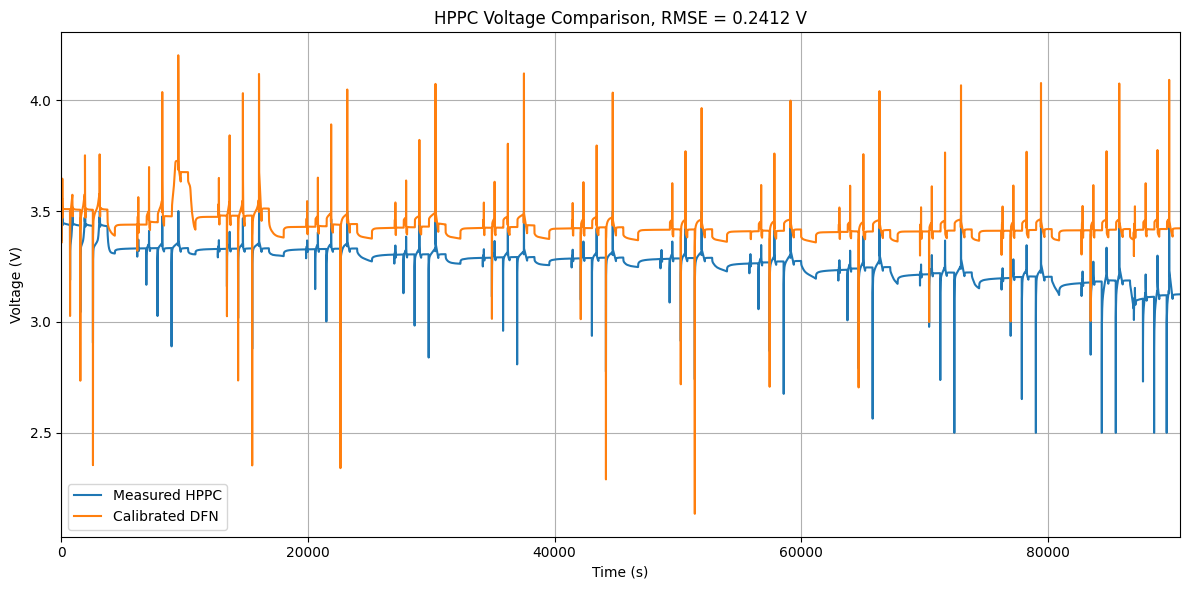

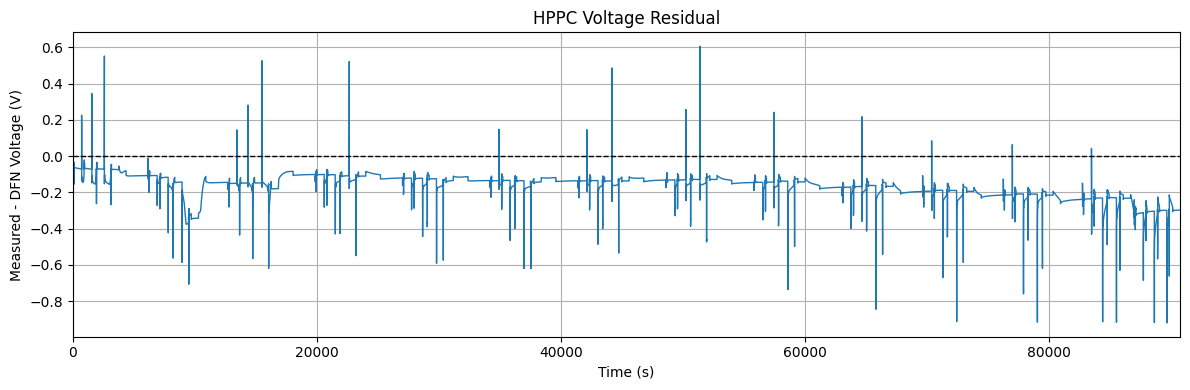

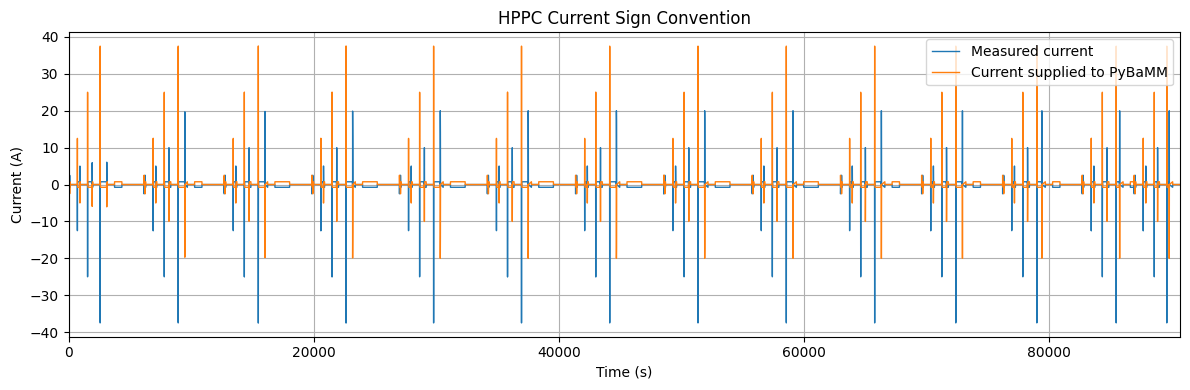

In [22]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# CALIBRATED MODEL SETTINGS
# =====================================================

theta_n_init = 0.905
theta_p_init = 0.5075

negative_thickness = 129e-6
positive_thickness = 171e-6

positive_active_fraction = 0.55
positive_particle_radius = 2.5e-6
positive_diffusivity = 5.9e-15

contact_resistance = 0.008
ocp_shift = 0.17

# =====================================================
# JOKAR LFP CATHODE OCP
# =====================================================

aa = 0.5

cath_soc = (1 - aa) + aa * (1 - np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
]))

cath_ocv = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

# Apply calibrated positive-electrode OCP shift
cath_ocv = cath_ocv + ocp_shift

# Sort OCP data
sort_idx = np.argsort(cath_soc)
cath_soc = cath_soc[sort_idx]
cath_ocv = cath_ocv[sort_idx]

# Remove nearly duplicated cathode stoichiometry values
ocp_keep = np.concatenate((
    [True],
    np.diff(cath_soc) > 1e-6
))

cath_soc = cath_soc[ocp_keep]
cath_ocv = cath_ocv[ocp_keep]

# Extend the OCP lookup domain to [0, 1]
sto_grid = np.linspace(0.0, 1.0, 1000)

ocv_grid = np.interp(
    sto_grid,
    cath_soc,
    cath_ocv,
    left=cath_ocv[0],
    right=cath_ocv[-1]
)

def custom_positive_ocp(sto):
    return pybamm.Interpolant(
        sto_grid,
        ocv_grid,
        sto,
        interpolator="linear"
    )

# =====================================================
# LOAD HPPC DATA
# =====================================================

hppc_data = loadmat(
    "HPPC_5458.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(meas.Time, dtype=float).reshape(-1)
current_raw = np.asarray(meas.Current, dtype=float).reshape(-1)
voltage_raw = np.asarray(meas.Voltage, dtype=float).reshape(-1)

# Make all raw arrays the same length
n_raw = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:n_raw]
current_raw = current_raw[:n_raw]
voltage_raw = voltage_raw[:n_raw]

# Remove NaN and infinite entries
finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

# Shift time to start at zero
time_raw = time_raw - time_raw[0]

# Sort by time before removing duplicates
time_order = np.argsort(time_raw, kind="stable")

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final sample at every duplicated timestamp.
# Reversing before np.unique makes the returned indices point
# to the last occurrence in the original sorted data.
_, reverse_unique_idx = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_idx = len(time_sorted) - 1 - reverse_unique_idx
last_idx = np.sort(last_idx)

time_exp = time_sorted[last_idx]
current_measured = current_sorted[last_idx]
voltage_exp = voltage_sorted[last_idx]

# Final strict-increase protection
strict_mask = np.concatenate((
    [True],
    np.diff(time_exp) > 0
))

time_exp = time_exp[strict_mask]
current_measured = current_measured[strict_mask]
voltage_exp = voltage_exp[strict_mask]

# PyBaMM convention:
# positive current = discharge, negative current = charge.
# The earlier comparison showed the experimental sign was reversed.
current_pybamm = -current_measured

print("Original HPPC samples :", n_raw)
print("Clean HPPC samples    :", len(time_exp))
print(
    "Strictly increasing   :",
    bool(np.all(np.diff(time_exp) > 0))
)
print(
    "Measured current range:",
    float(np.min(current_measured)),
    "to",
    float(np.max(current_measured)),
    "A"
)
print(
    "PyBaMM current range  :",
    float(np.min(current_pybamm)),
    "to",
    float(np.max(current_pybamm)),
    "A"
)
print(
    "HPPC duration         :",
    float(time_exp[-1]),
    "s"
)

if len(time_exp) < 2:
    raise ValueError(
        "HPPC data has fewer than two unique timestamps."
    )

# =====================================================
# BUILD HPPC CURRENT INTERPOLANT
# =====================================================

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

# =====================================================
# BUILD CALIBRATED PRADA2013 PARAMETER SET
# =====================================================

params = pybamm.ParameterValues("Prada2013")

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

params.update({
    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        negative_thickness,

    "Positive electrode thickness [m]":
        positive_thickness,

    "Positive electrode active material volume fraction":
        positive_active_fraction,

    "Positive particle radius [m]":
        positive_particle_radius,

    "Positive electrode diffusivity [m2.s-1]":
        positive_diffusivity,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        contact_resistance
})

# =====================================================
# DFN MODEL AND SOLVER
# =====================================================

model = pybamm.lithium_ion.DFN()

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver
)

# =====================================================
# RUN DFN WITH HPPC PROFILE
# =====================================================

solution = simulation.solve(
    t_eval=time_exp
)

time_model = solution["Time [s]"].entries
voltage_model = solution["Terminal voltage [V]"].entries

if len(time_model) < 2:
    raise RuntimeError(
        "DFN returned fewer than two time points."
    )

# =====================================================
# COMPARE ONLY OVER THE VALID OVERLAPPING TIME
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1])
)

valid_mask = time_exp <= t_valid_end

time_exp_valid = time_exp[valid_mask]
voltage_exp_valid = voltage_exp[valid_mask]
current_measured_valid = current_measured[valid_mask]
current_pybamm_valid = current_pybamm[valid_mask]

voltage_interp = np.interp(
    time_exp_valid,
    time_model,
    voltage_model
)

error = voltage_exp_valid - voltage_interp

rmse = np.sqrt(np.mean(error ** 2))
mae = np.mean(np.abs(error))
max_error = np.max(np.abs(error))
mean_error = np.mean(error)

print()
print("================================")
print("CORRECTED HPPC DFN VALIDATION")
print("================================")
print("Current sign reversed       : Yes")
print("Experimental duration (s)   :", float(time_exp[-1]))
print("DFN solution duration (s)   :", float(time_model[-1]))
print("Compared duration (s)       :", t_valid_end)
print("Compared samples            :", len(time_exp_valid))
print("RMSE (V)                    :", rmse)
print("MAE (V)                     :", mae)
print("Maximum error (V)           :", max_error)
print("Mean signed error (V)       :", mean_error)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(figsize=(12, 6))

plt.plot(
    time_exp_valid,
    voltage_exp_valid,
    linewidth=1.5,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.5,
    label="Calibrated DFN"
)

plt.xlim(0, t_valid_end)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(
    f"HPPC Voltage Comparison, RMSE = {rmse:.4f} V"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(figsize=(12, 4))

plt.plot(
    time_exp_valid,
    error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

plt.xlim(0, t_valid_end)
plt.xlabel("Time (s)")
plt.ylabel("Measured - DFN Voltage (V)")
plt.title("HPPC Voltage Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# MEASURED AND PYBAMM CURRENT PROFILES
# =====================================================

plt.figure(figsize=(12, 4))

plt.plot(
    time_exp_valid,
    current_measured_valid,
    linewidth=1.0,
    label="Measured current"
)

plt.plot(
    time_exp_valid,
    current_pybamm_valid,
    linewidth=1.0,
    label="Current supplied to PyBaMM"
)

plt.xlim(0, t_valid_end)
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("HPPC Current Sign Convention")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
#Improving HPPC response
# IVs are not optimised for HPPC, done for 1C

In [23]:
net_ah_measured = np.trapz(current_measured, time_exp) / 3600
net_ah_pybamm = np.trapz(current_pybamm, time_exp) / 3600

print("Measured signed Ah =", net_ah_measured)
print("PyBaMM signed Ah   =", net_ah_pybamm)
print("Cell capacity      =", params["Nominal cell capacity [A.h]"])

Measured signed Ah = -2.124456016320968
PyBaMM signed Ah   = 2.124456016320968
Cell capacity      = 1.1


In [24]:
rest = np.abs(current_pybamm) < 0.05

baseline_rmse = np.sqrt(
    np.mean(
        (
            voltage_exp[rest] -
            voltage_interp[rest]
        ) ** 2
    )
)

baseline_bias = np.mean(
    voltage_exp[rest] -
    voltage_interp[rest]
)

print("Rest-period RMSE =", baseline_rmse)
print("Rest-period bias =", baseline_bias)

Rest-period RMSE = 0.19048846120711513
Rest-period bias = -0.17465478304462057


In [ ]:
# run HPPC for shorter period

Clean HPPC samples     : 6996
HPPC duration (s)      : 8991.105999425054
Strictly increasing    : True
Theta n initial        : 0.905
Theta p initial        : 0.5075
OCP shift (V)          : 0.1
Contact resistance     : 0.0
Positive diffusivity   : 1e-13
Measured current range : -37.4989 to 9.9996 A
PyBaMM current range   : -9.9996 to 37.4989 A
Original electrolyte conductivity type: <class 'function'>
Original electrolyte diffusivity type: <class 'function'>
Electrolyte conductivity multiplier = 1.6
Electrolyte diffusivity multiplier  = 1.0
Positive exchange-current multiplier = 30.0
Negative exchange-current multiplier = 30.0

INITIAL 2000 s HPPC VALIDATION
DFN duration (s)          : 8991.105999425054
Compared duration (s)     : 8991.105999425054
Compared samples          : 6996
Measured signed Ah        : -0.22711927949767566
PyBaMM signed Ah          : 0.22711927949767566

Overall RMSE (V)          : 0.03638016290277173
Overall MAE (V)           : 0.031310672691910395
Maximum erro

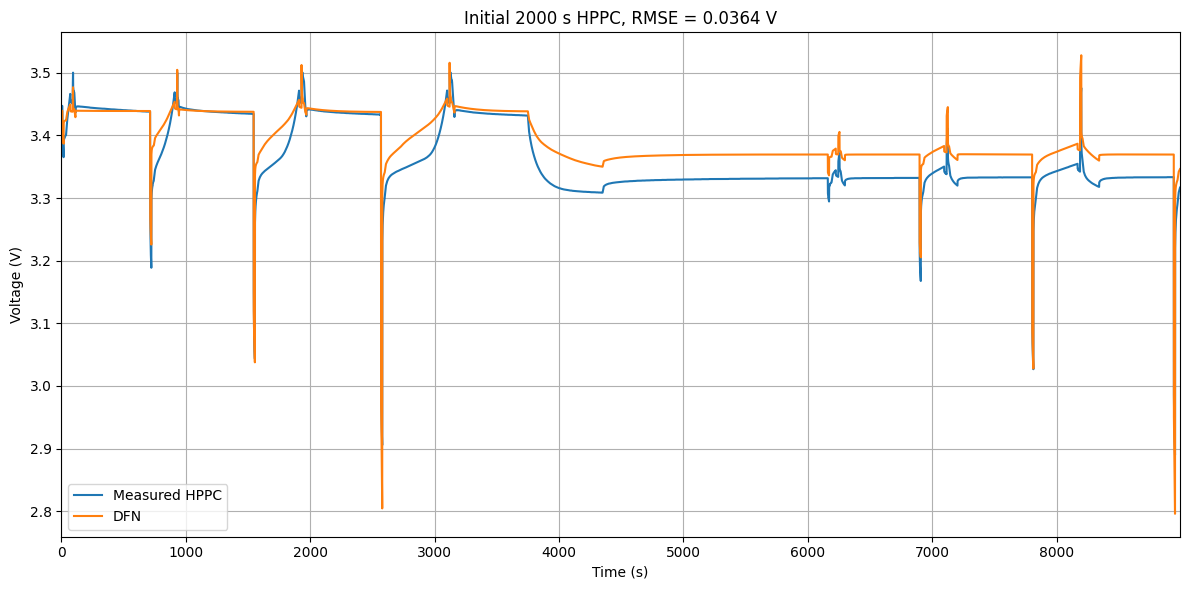

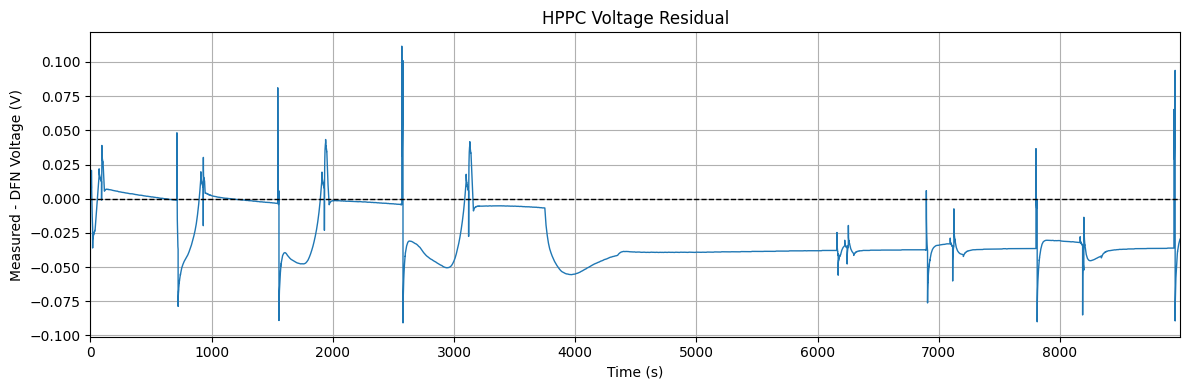

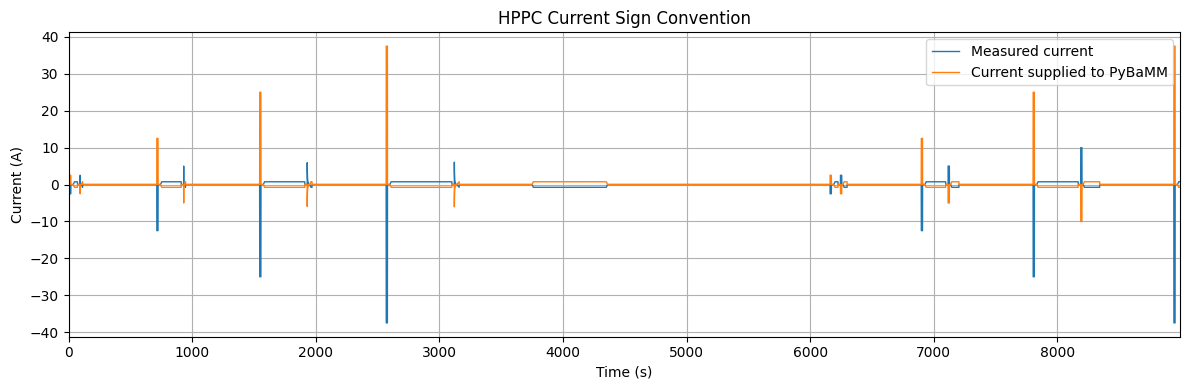

In [49]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# USER SETTINGS
# =====================================================

theta_n_init = 0.905
theta_p_init = 0.5075

ocp_shift = 0.10
contact_resistance = 0.000

#positive_diffusivity = 5.9e-15
positive_diffusivity = 10e-14
positive_particle_radius = 2.5e-6

negative_thickness = 129e-6
positive_thickness = 171e-6
positive_active_fraction = 0.55

t_compare = 9000.0

rest_current_threshold = 0.05
pulse_current_threshold = 5.0

# =====================================================
# JOKAR CATHODE OCP DATA
# =====================================================

aa = 0.5

raw_cathode_axis = np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
])

cath_soc = (
    (1.0 - aa)
    + aa * (1.0 - raw_cathode_axis)
)

cath_ocv = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

# Apply calibrated cathode OCP voltage offset
cath_ocv = cath_ocv + ocp_shift

# Sort by cathode stoichiometry
ocp_order = np.argsort(
    cath_soc,
    kind="stable"
)

cath_soc = cath_soc[ocp_order]
cath_ocv = cath_ocv[ocp_order]

# Remove duplicate or nearly duplicate stoichiometry points
ocp_keep = np.concatenate((
    [True],
    np.diff(cath_soc) > 1e-6
))

cath_soc = cath_soc[ocp_keep]
cath_ocv = cath_ocv[ocp_keep]

# Extend the cathode OCP lookup to [0, 1]
sto_grid = np.linspace(
    0.0,
    1.0,
    1000
)

ocv_grid = np.interp(
    sto_grid,
    cath_soc,
    cath_ocv,
    left=cath_ocv[0],
    right=cath_ocv[-1]
)

def custom_positive_ocp(sto):
    return pybamm.Interpolant(
        sto_grid,
        ocv_grid,
        sto,
        interpolator="linear"
    )

# =====================================================
# LOAD HPPC DATA
# =====================================================

hppc_data = loadmat(
    "HPPC_5458.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(
    meas.Time,
    dtype=float
).reshape(-1)

current_raw = np.asarray(
    meas.Current,
    dtype=float
).reshape(-1)

voltage_raw = np.asarray(
    meas.Voltage,
    dtype=float
).reshape(-1)

# Make all arrays equal in length
number_of_raw_points = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:number_of_raw_points]
current_raw = current_raw[:number_of_raw_points]
voltage_raw = voltage_raw[:number_of_raw_points]

# Remove NaN and infinite entries
finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

# Start experimental time at zero
time_raw = time_raw - time_raw[0]

# Keep only the first 2000 seconds
window_mask = (
    (time_raw >= 0.0)
    & (time_raw <= t_compare)
)

time_raw = time_raw[window_mask]
current_raw = current_raw[window_mask]
voltage_raw = voltage_raw[window_mask]

# Sort all samples by time
time_order = np.argsort(
    time_raw,
    kind="stable"
)

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final sample at each duplicated timestamp
_, reverse_unique_index = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_index = (
    len(time_sorted)
    - 1
    - reverse_unique_index
)

last_index = np.sort(last_index)

time_exp = time_sorted[last_index]
current_measured = current_sorted[last_index]
voltage_exp = voltage_sorted[last_index]

# Final strict-increase time filter
strict_time_mask = np.concatenate((
    [True],
    np.diff(time_exp) > 0.0
))

time_exp = time_exp[strict_time_mask]
current_measured = current_measured[strict_time_mask]
voltage_exp = voltage_exp[strict_time_mask]

if len(time_exp) < 2:
    raise ValueError(
        "Fewer than two unique HPPC timestamps remain."
    )

if not np.all(np.diff(time_exp) > 0.0):
    raise ValueError(
        "HPPC time vector is not strictly increasing."
    )

# Experimental current sign is opposite to PyBaMM convention
current_pybamm = -current_measured

print("Clean HPPC samples     :", len(time_exp))
print("HPPC duration (s)      :", time_exp[-1])
print(
    "Strictly increasing    :",
    np.all(np.diff(time_exp) > 0.0)
)
print("Theta n initial        :", theta_n_init)
print("Theta p initial        :", theta_p_init)
print("OCP shift (V)          :", ocp_shift)
print("Contact resistance     :", contact_resistance)
print("Positive diffusivity   :", positive_diffusivity)
print(
    "Measured current range :",
    current_measured.min(),
    "to",
    current_measured.max(),
    "A"
)
print(
    "PyBaMM current range   :",
    current_pybamm.min(),
    "to",
    current_pybamm.max(),
    "A"
)

# =====================================================
# HPPC CURRENT INTERPOLANT
# =====================================================

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

# =====================================================
# BUILD PARAMETER SET
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

# =====================================================
# ELECTROLYTE TRANSPORT MULTIPLIERS
# =====================================================

electrolyte_conductivity_multiplier = 1.6
electrolyte_diffusivity_multiplier = 1.0

# Store original Prada2013 electrolyte functions
original_electrolyte_conductivity = params[
    "Electrolyte conductivity [S.m-1]"
]

original_electrolyte_diffusivity = params[
    "Electrolyte diffusivity [m2.s-1]"
]

print(
    "Original electrolyte conductivity type:",
    type(original_electrolyte_conductivity)
)

print(
    "Original electrolyte diffusivity type:",
    type(original_electrolyte_diffusivity)
)

# Scale electrolyte conductivity
def scaled_electrolyte_conductivity(c_e, T):

    return (
        electrolyte_conductivity_multiplier
        * original_electrolyte_conductivity(c_e, T)
    )

# Scale electrolyte diffusivity
def scaled_electrolyte_diffusivity(c_e, T):

    return (
        electrolyte_diffusivity_multiplier
        * original_electrolyte_diffusivity(c_e, T)
    )

# Apply electrolyte transport multipliers
params.update({

    "Electrolyte conductivity [S.m-1]":
        scaled_electrolyte_conductivity,

    "Electrolyte diffusivity [m2.s-1]":
        scaled_electrolyte_diffusivity

})

print(
    "Electrolyte conductivity multiplier =",
    electrolyte_conductivity_multiplier
)

print(
    "Electrolyte diffusivity multiplier  =",
    electrolyte_diffusivity_multiplier
)

# =====================================================
# EXCHANGE-CURRENT DENSITY MULTIPLIERS
# =====================================================

positive_kinetic_multiplier = 30.0
negative_kinetic_multiplier = 30.0

# Store original Prada2013 functions before updating params
original_positive_j0 = params[
    "Positive electrode exchange-current density [A.m-2]"
]

original_negative_j0 = params[
    "Negative electrode exchange-current density [A.m-2]"
]

# Scale positive-electrode exchange-current density
def scaled_positive_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    T
):
    return (
        positive_kinetic_multiplier
        * original_positive_j0(
            c_e,
            c_s_surf,
            c_s_max,
            T
        )
    )

# Scale negative-electrode exchange-current density
def scaled_negative_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    T
):
    return (
        negative_kinetic_multiplier
        * original_negative_j0(
            c_e,
            c_s_surf,
            c_s_max,
            T
        )
    )

# Apply both kinetic multipliers
params.update({
    "Positive electrode exchange-current density [A.m-2]":
        scaled_positive_exchange_current_density,

    "Negative electrode exchange-current density [A.m-2]":
        scaled_negative_exchange_current_density
})

print(
    "Positive exchange-current multiplier =",
    positive_kinetic_multiplier
)

print(
    "Negative exchange-current multiplier =",
    negative_kinetic_multiplier
)

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

params.update({
    "Nominal cell capacity [A.h]": 2.5,

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        129e-6,

    "Positive electrode thickness [m]":
        171e-6,

    "Positive electrode active material volume fraction":
        0.55,

    "Positive particle radius [m]":
        2.5e-6,

    "Positive electrode diffusivity [m2.s-1]":
        1e-13,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        0.0
})

# =====================================================
# DFN WITH CONTACT RESISTANCE ENABLED
# =====================================================

model = pybamm.lithium_ion.DFN(
    options={
        "contact resistance": "true"
    }
)

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver
)

# =====================================================
# RUN DFN
# =====================================================

solution = simulation.solve(
    t_eval=time_exp
)

time_model = np.asarray(
    solution["Time [s]"].entries,
    dtype=float
).reshape(-1)

voltage_model = np.asarray(
    solution["Terminal voltage [V]"].entries,
    dtype=float
).reshape(-1)

if len(time_model) < 2:
    raise RuntimeError(
        "DFN returned fewer than two time points."
    )

# =====================================================
# VALID COMPARISON WINDOW
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1]),
    t_compare
)

valid_mask = time_exp <= t_valid_end

time_valid = time_exp[valid_mask]
voltage_valid = voltage_exp[valid_mask]
current_valid = current_measured[valid_mask]

voltage_interpolated = np.interp(
    time_valid,
    time_model,
    voltage_model
)

voltage_error = (
    voltage_valid
    - voltage_interpolated
)

# =====================================================
# OVERALL ERROR METRICS
# =====================================================

rmse = float(
    np.sqrt(
        np.mean(
            voltage_error ** 2
        )
    )
)

mae = float(
    np.mean(
        np.abs(voltage_error)
    )
)

maximum_error = float(
    np.max(
        np.abs(voltage_error)
    )
)

mean_bias = float(
    np.mean(voltage_error)
)

# =====================================================
# SEGMENTED ERROR METRICS
# =====================================================

rest_mask = (
    np.abs(current_valid)
    < rest_current_threshold
)

pulse_mask = (
    np.abs(current_valid)
    > pulse_current_threshold
)

relaxation_mask = (
    ~rest_mask
    & ~pulse_mask
)

def calculate_masked_rmse(mask_values):
    if np.any(mask_values):
        return float(
            np.sqrt(
                np.mean(
                    voltage_error[mask_values] ** 2
                )
            )
        )
    return np.nan

def calculate_masked_bias(mask_values):
    if np.any(mask_values):
        return float(
            np.mean(
                voltage_error[mask_values]
            )
        )
    return np.nan

rest_rmse = calculate_masked_rmse(
    rest_mask
)

pulse_rmse = calculate_masked_rmse(
    pulse_mask
)

relaxation_rmse = calculate_masked_rmse(
    relaxation_mask
)

rest_bias = calculate_masked_bias(
    rest_mask
)

pulse_bias = calculate_masked_bias(
    pulse_mask
)

relaxation_bias = calculate_masked_bias(
    relaxation_mask
)

segmented_values = np.array([
    rest_rmse,
    pulse_rmse,
    relaxation_rmse
])

if np.all(np.isfinite(segmented_values)):
    segmented_cost = (
        0.20 * rest_rmse
        + 0.50 * pulse_rmse
        + 0.30 * relaxation_rmse
    )
else:
    segmented_cost = np.nan

# =====================================================
# CAPACITY OVER ANALYZED WINDOW
# =====================================================

if hasattr(np, "trapezoid"):
    measured_signed_ah = float(
        np.trapezoid(
            current_valid,
            time_valid
        ) / 3600.0
    )

    pybamm_signed_ah = float(
        np.trapezoid(
            -current_valid,
            time_valid
        ) / 3600.0
    )
else:
    measured_signed_ah = float(
        np.trapz(
            current_valid,
            time_valid
        ) / 3600.0
    )

    pybamm_signed_ah = float(
        np.trapz(
            -current_valid,
            time_valid
        ) / 3600.0
    )

# =====================================================
# PRINT RESULTS
# =====================================================

print()
print("================================")
print("HPPC VALIDATION")
print("================================")
print("DFN duration (s)          :", time_model[-1])
print("Compared duration (s)     :", t_valid_end)
print("Compared samples          :", len(time_valid))
print("Measured signed Ah        :", measured_signed_ah)
print("PyBaMM signed Ah          :", pybamm_signed_ah)
print()
print("Overall RMSE (V)          :", rmse)
print("Overall MAE (V)           :", mae)
print("Maximum error (V)         :", maximum_error)
print("Mean signed error (V)     :", mean_bias)
print()
print("Rest RMSE (V)             :", rest_rmse)
print("Rest bias (V)             :", rest_bias)
print("Pulse RMSE (V)            :", pulse_rmse)
print("Pulse bias (V)            :", pulse_bias)
print("Relaxation RMSE (V)       :", relaxation_rmse)
print("Relaxation bias (V)       :", relaxation_bias)
print("Segmented cost (V)        :", segmented_cost)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    time_valid,
    voltage_valid,
    linewidth=1.5,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.5,
    label="DFN"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Voltage (V)"
)

plt.title(
    f"HPPC validation, RMSE = {rmse:.4f} V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    time_valid,
    voltage_error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Measured - DFN Voltage (V)"
)

plt.title(
    "HPPC Voltage Residual"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# CURRENT PROFILE
# =====================================================

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    time_valid,
    current_valid,
    linewidth=1.0,
    label="Measured current"
)

plt.plot(
    time_valid,
    -current_valid,
    linewidth=1.0,
    label="Current supplied to PyBaMM"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Current (A)"
)

plt.title(
    "HPPC Current Sign Convention"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

absolute_throughput_ah = integrate(
    np.abs(current_valid),
    time_valid
) / 3600.0

print("Absolute HPPC throughput =", absolute_throughput_ah, "Ah")

Absolute HPPC throughput = 0.9902053180893883 Ah


Final net discharge = 0.2257080270443116 Ah
Final absolute throughput = 1.005263964693993 Ah
Estimated final SOC = 0.9097167891822754


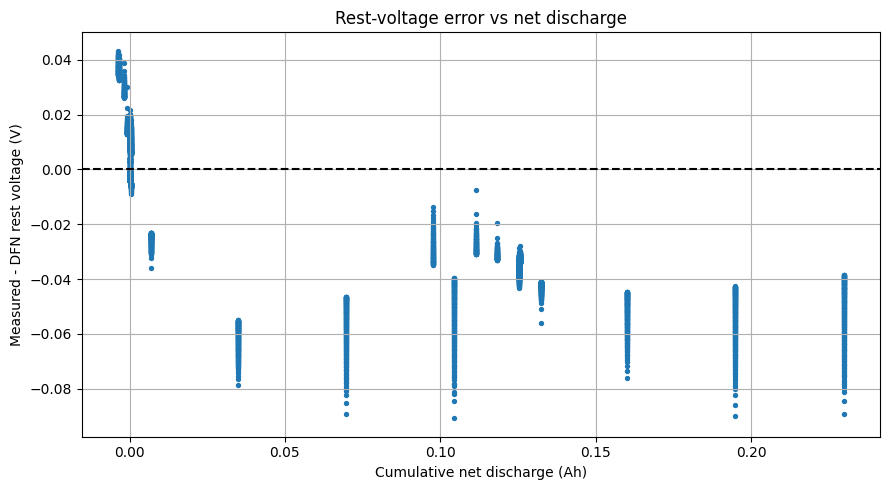

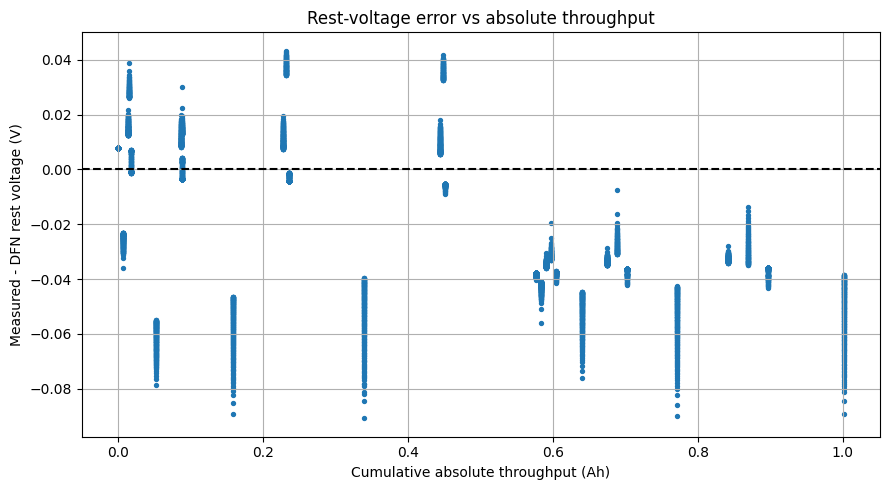

In [51]:
# =====================================================
# REST-VOLTAGE DRIFT DIAGNOSTIC
# =====================================================

current_pybamm_valid = -current_valid

dt = np.diff(
    time_valid,
    prepend=time_valid[0]
)

net_discharge_ah = np.cumsum(
    current_pybamm_valid * dt
) / 3600.0

absolute_throughput_ah = np.cumsum(
    np.abs(current_pybamm_valid) * dt
) / 3600.0

cell_capacity_ah = 2.5

soc_from_coulomb_counting = (
    1.0 - net_discharge_ah / cell_capacity_ah
)

rest_mask = np.abs(current_valid) < 0.05

print(
    "Final net discharge =",
    net_discharge_ah[-1],
    "Ah"
)

print(
    "Final absolute throughput =",
    absolute_throughput_ah[-1],
    "Ah"
)

print(
    "Estimated final SOC =",
    soc_from_coulomb_counting[-1]
)

plt.figure(figsize=(9, 5))

plt.scatter(
    net_discharge_ah[rest_mask],
    voltage_error[rest_mask],
    s=8
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--"
)

plt.xlabel("Cumulative net discharge (Ah)")
plt.ylabel("Measured - DFN rest voltage (V)")
plt.title("Rest-voltage error vs net discharge")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

plt.scatter(
    absolute_throughput_ah[rest_mask],
    voltage_error[rest_mask],
    s=8
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--"
)

plt.xlabel("Cumulative absolute throughput (Ah)")
plt.ylabel("Measured - DFN rest voltage (V)")
plt.title("Rest-voltage error vs absolute throughput")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#now we need to fix charging ocv to counter hysteresis

1C: 3337 points, SOC 0.0000 to 0.9380, current 1.758 to 2.501 A
2C: 1679 points, SOC 0.0000 to 0.9344, current 3.525 to 5.001 A
3C: 1113 points, SOC 0.0000 to 0.9267, current 5.289 to 7.501 A
4C: 818 points, SOC 0.0000 to 0.9126, current 7.023 to 10.002 A

Common SOC range: 0.02 to 0.9125592646514331

CHARGE OCV EXTRACTION SUMMARY
Common SOC range           : 0.02 to 0.9125592646514331
Charge cell OCV range (V)  : 3.103483655131189 to 3.434933251505969
Charge cathode OCP range   : 3.4550781937185264 to 3.6426657078697446
Mean zero-current fit R2   : 0.9959733400824843
Minimum zero-current fit R2: 0.8205728575898976


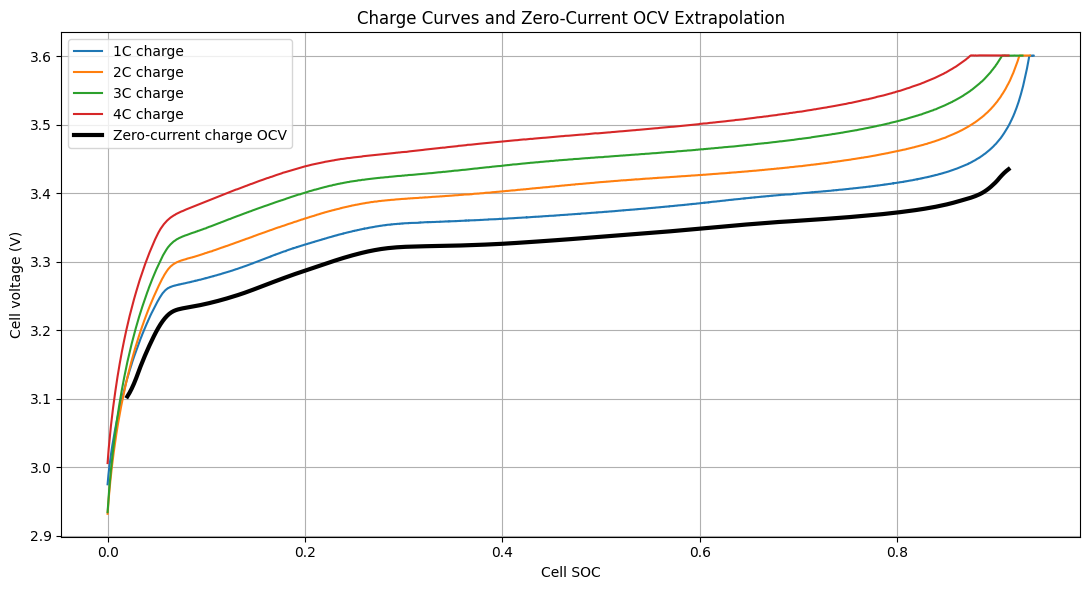

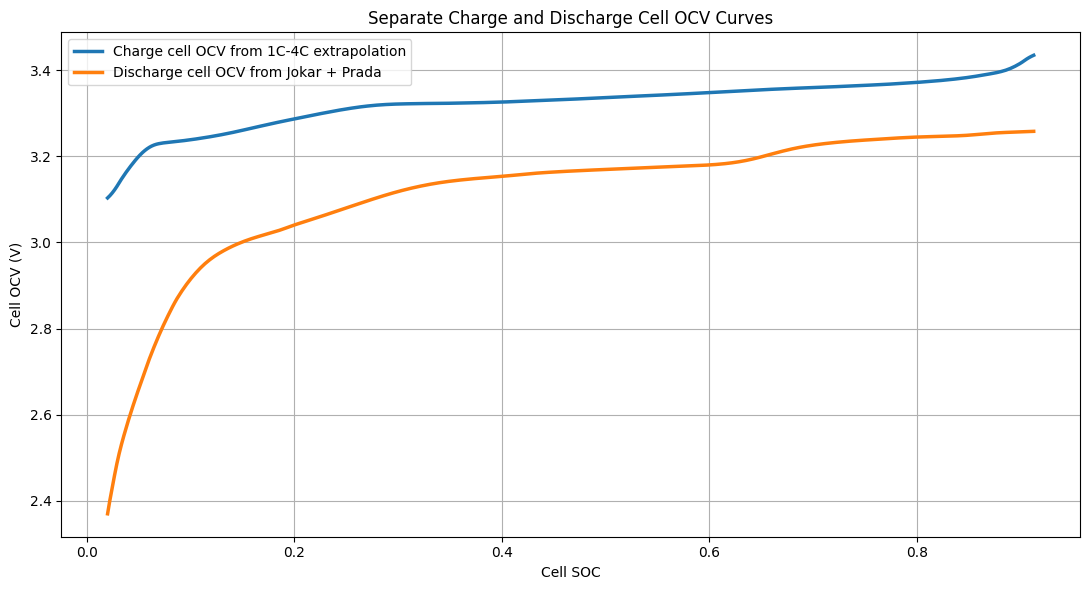

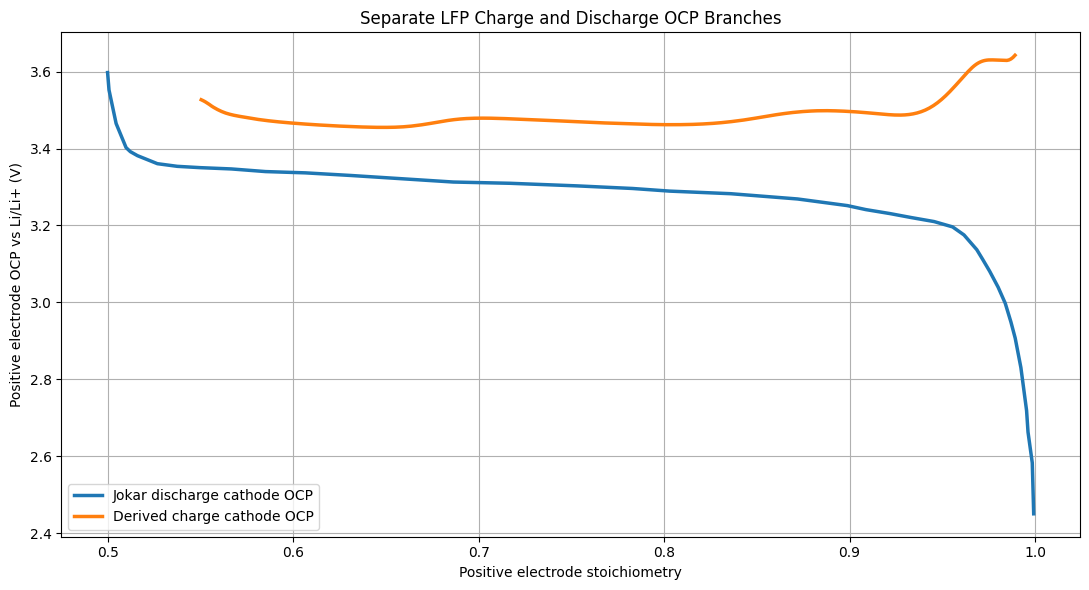

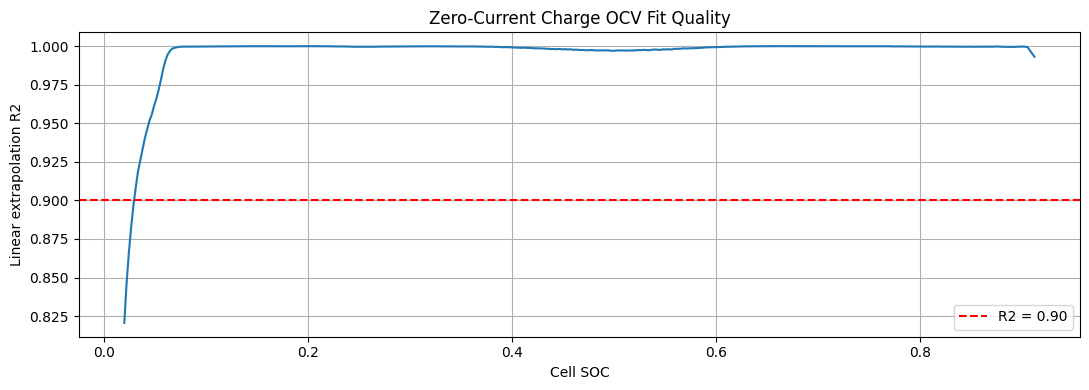


PyBaMM-ready discharge branch:
theta_p_discharge = (41,)
U_p_discharge     = (41,)

PyBaMM-ready charge branch:
theta_p_charge    = (400,)
U_p_charge        = (400,)


In [52]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator

# =====================================================
# USER SETTINGS
# =====================================================

cell_capacity_ah = 2.5

charge_files = {
    1.0: "Charge_1C_9330.mat",
    2.0: "Charge_2C_8642.mat",
    3.0: "Charge_3C_1216.mat",
    4.0: "Charge_4C_1562.mat",
}

# Electrode stoichiometric limits used to convert
# cell OCV into cathode OCP with the Prada graphite OCP.
theta_n_at_soc_0 = 0.05
theta_n_at_soc_1 = 0.905

theta_p_at_soc_0 = 0.999
theta_p_at_soc_1 = 0.5075

# Avoid the extreme endpoints during extrapolation.
soc_lower_limit = 0.02
soc_upper_limit = 0.98
number_of_soc_points = 400

# Minimum allowable current relative to nominal C-rate.
# This removes rest/CV-tail samples from each charging curve.
minimum_current_fraction = 0.70

# Optional smoothing window for the derived charge OCV.
# Set to 1 to disable smoothing.
smoothing_window = 9

# =====================================================
# HELPER: LOAD A CHARGE FILE
# =====================================================

def load_charge_file(filename):

    mat_data = loadmat(
        filename,
        squeeze_me=True,
        struct_as_record=False
    )

    if "meas" in mat_data:
        obj = mat_data["meas"]
        time = np.asarray(obj.Time, dtype=float).reshape(-1)
        current = np.asarray(obj.Current, dtype=float).reshape(-1)
        voltage = np.asarray(obj.Voltage, dtype=float).reshape(-1)
    else:
        time = np.asarray(mat_data["Time"], dtype=float).reshape(-1)
        current = np.asarray(mat_data["Current"], dtype=float).reshape(-1)
        voltage = np.asarray(mat_data["Voltage"], dtype=float).reshape(-1)

    n = min(
        len(time),
        len(current),
        len(voltage)
    )

    time = time[:n]
    current = current[:n]
    voltage = voltage[:n]

    finite = (
        np.isfinite(time)
        & np.isfinite(current)
        & np.isfinite(voltage)
    )

    time = time[finite]
    current = current[finite]
    voltage = voltage[finite]

    time = time - time[0]

    # Sort by time.
    order = np.argsort(
        time,
        kind="stable"
    )

    time = time[order]
    current = current[order]
    voltage = voltage[order]

    # Keep the final value at duplicated timestamps.
    _, reverse_index = np.unique(
        time[::-1],
        return_index=True
    )

    last_index = (
        len(time)
        - 1
        - reverse_index
    )

    last_index = np.sort(last_index)

    time = time[last_index]
    current = current[last_index]
    voltage = voltage[last_index]

    # Final strict-increase check.
    strict = np.concatenate((
        [True],
        np.diff(time) > 0
    ))

    time = time[strict]
    current = current[strict]
    voltage = voltage[strict]

    if len(time) < 2:
        raise ValueError(
            f"{filename} has fewer than two unique timestamps."
        )

    return time, current, voltage

# =====================================================
# HELPER: MOVING-AVERAGE SMOOTHING
# =====================================================

def smooth_curve(values, window):

    if window <= 1:
        return values.copy()

    if window % 2 == 0:
        window = window + 1

    pad = window // 2

    padded = np.pad(
        values,
        pad_width=pad,
        mode="edge"
    )

    kernel = np.ones(window) / window

    return np.convolve(
        padded,
        kernel,
        mode="valid"
    )

# =====================================================
# LOAD AND PROCESS ALL CHARGE CURVES
# =====================================================

charge_data = {}

for nominal_c_rate, filename in charge_files.items():

    time, current, voltage = load_charge_file(filename)

    # The magnitude is used for coulomb counting because file sign
    # conventions can vary.
    current_magnitude = np.abs(current)

    # Nominal current for the reported C-rate.
    nominal_current = (
        nominal_c_rate
        * cell_capacity_ah
    )

    # Keep the constant-current charging region.
    cc_mask = (
        current_magnitude
        >= minimum_current_fraction * nominal_current
    )

    if np.sum(cc_mask) < 5:
        raise ValueError(
            f"Not enough constant-current points in {filename}. "
            f"Check current sign, units, or current threshold."
        )

    time_cc = time[cc_mask]
    current_cc = current_magnitude[cc_mask]
    voltage_cc = voltage[cc_mask]

    # Reset the selected CC interval to zero time.
    time_cc = time_cc - time_cc[0]

    # Charge throughput in Ah.
    charged_ah = cumulative_trapezoid(
        current_cc,
        time_cc,
        initial=0.0
    ) / 3600.0

    # Cell SOC based on the known 2.5 Ah capacity.
    soc = charged_ah / cell_capacity_ah

    valid = (
        (soc >= 0.0)
        & (soc <= 1.0)
        & np.isfinite(soc)
        & np.isfinite(voltage_cc)
        & np.isfinite(current_cc)
    )

    soc = soc[valid]
    voltage_cc = voltage_cc[valid]
    current_cc = current_cc[valid]
    time_cc = time_cc[valid]

    # Remove duplicate SOC values.
    soc_unique, unique_idx = np.unique(
        soc,
        return_index=True
    )

    voltage_unique = voltage_cc[unique_idx]
    current_unique = current_cc[unique_idx]
    time_unique = time_cc[unique_idx]

    # Actual C-rate at every retained sample.
    actual_c_rate = (
        current_unique
        / cell_capacity_ah
    )

    charge_data[nominal_c_rate] = {
        "filename": filename,
        "time": time_unique,
        "soc": soc_unique,
        "voltage": voltage_unique,
        "current": current_unique,
        "c_rate": actual_c_rate,
    }

    print(
        f"{nominal_c_rate:.0f}C: "
        f"{len(soc_unique)} points, "
        f"SOC {soc_unique.min():.4f} to {soc_unique.max():.4f}, "
        f"current {current_unique.min():.3f} to "
        f"{current_unique.max():.3f} A"
    )

# =====================================================
# FIND COMMON SOC RANGE
# =====================================================

common_soc_min = max(
    soc_lower_limit,
    max(
        dataset["soc"].min()
        for dataset in charge_data.values()
    )
)

common_soc_max = min(
    soc_upper_limit,
    min(
        dataset["soc"].max()
        for dataset in charge_data.values()
    )
)

if common_soc_max <= common_soc_min:
    raise ValueError(
        "The charging datasets do not have a common SOC range. "
        "Check capacity, current threshold, or file contents."
    )

soc_common = np.linspace(
    common_soc_min,
    common_soc_max,
    number_of_soc_points
)

print()
print(
    "Common SOC range:",
    common_soc_min,
    "to",
    common_soc_max
)

# =====================================================
# INTERPOLATE EACH RATE ONTO COMMON SOC
# =====================================================

rates_sorted = np.array(
    sorted(charge_data.keys()),
    dtype=float
)

voltage_matrix = []
current_matrix = []

for nominal_c_rate in rates_sorted:

    dataset = charge_data[nominal_c_rate]

    voltage_interpolator = PchipInterpolator(
        dataset["soc"],
        dataset["voltage"],
        extrapolate=False
    )

    current_interpolator = PchipInterpolator(
        dataset["soc"],
        dataset["current"],
        extrapolate=False
    )

    voltage_matrix.append(
        voltage_interpolator(soc_common)
    )

    current_matrix.append(
        current_interpolator(soc_common)
    )

voltage_matrix = np.asarray(voltage_matrix)
current_matrix = np.asarray(current_matrix)

# =====================================================
# ZERO-CURRENT EXTRAPOLATION
#
# At each SOC:
# V_charge(I, SOC) = OCV_charge(SOC) + polarization * I
#
# The zero-current intercept is the estimated charge OCV.
# =====================================================

charge_cell_ocv = np.empty_like(soc_common)
polarization_slope = np.empty_like(soc_common)
fit_r_squared = np.empty_like(soc_common)

for index in range(len(soc_common)):

    current_at_soc = current_matrix[:, index]
    voltage_at_soc = voltage_matrix[:, index]

    valid = (
        np.isfinite(current_at_soc)
        & np.isfinite(voltage_at_soc)
    )

    current_at_soc = current_at_soc[valid]
    voltage_at_soc = voltage_at_soc[valid]

    if len(current_at_soc) < 2:
        charge_cell_ocv[index] = np.nan
        polarization_slope[index] = np.nan
        fit_r_squared[index] = np.nan
        continue

    # Linear fit of voltage versus charging current.
    slope, intercept = np.polyfit(
        current_at_soc,
        voltage_at_soc,
        1
    )

    predicted = (
        slope * current_at_soc
        + intercept
    )

    residual_sum = np.sum(
        (voltage_at_soc - predicted) ** 2
    )

    total_sum = np.sum(
        (
            voltage_at_soc
            - np.mean(voltage_at_soc)
        ) ** 2
    )

    charge_cell_ocv[index] = intercept
    polarization_slope[index] = slope

    if total_sum > 0:
        fit_r_squared[index] = (
            1.0
            - residual_sum / total_sum
        )
    else:
        fit_r_squared[index] = np.nan

# Remove any invalid extrapolated entries.
valid_ocv = (
    np.isfinite(charge_cell_ocv)
    & np.isfinite(soc_common)
)

soc_common = soc_common[valid_ocv]
charge_cell_ocv = charge_cell_ocv[valid_ocv]
polarization_slope = polarization_slope[valid_ocv]
fit_r_squared = fit_r_squared[valid_ocv]

voltage_matrix = voltage_matrix[:, valid_ocv]
current_matrix = current_matrix[:, valid_ocv]

# Smooth the zero-current charge OCV.
charge_cell_ocv_smooth = smooth_curve(
    charge_cell_ocv,
    smoothing_window
)

# =====================================================
# PRADA GRAPHITE ANODE OCP
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

graphite_ocp_function = params[
    "Negative electrode OCP [V]"
]

# Electrode stoichiometry versus cell SOC.
theta_n = (
    theta_n_at_soc_0
    + soc_common
    * (
        theta_n_at_soc_1
        - theta_n_at_soc_0
    )
)

theta_p = (
    theta_p_at_soc_0
    + soc_common
    * (
        theta_p_at_soc_1
        - theta_p_at_soc_0
    )
)

graphite_ocp = np.array([
    float(
        graphite_ocp_function(
            pybamm.Scalar(theta)
        ).evaluate()
    )
    for theta in theta_n
])

# =====================================================
# CHARGING CATHODE OCP
#
# U_cell = U_positive - U_negative
# Therefore:
# U_positive = U_cell + U_negative
# =====================================================

charge_cathode_ocp = (
    charge_cell_ocv_smooth
    + graphite_ocp
)

# Sort by cathode stoichiometry for later PyBaMM use.
charge_cathode_order = np.argsort(theta_p)

theta_p_charge = theta_p[charge_cathode_order]
charge_cathode_ocp = charge_cathode_ocp[charge_cathode_order]

# Remove duplicate theta_p entries.
theta_p_charge, charge_unique_idx = np.unique(
    theta_p_charge,
    return_index=True
)

charge_cathode_ocp = charge_cathode_ocp[
    charge_unique_idx
]

# =====================================================
# JOKAR DISCHARGE CATHODE OCP
# =====================================================

aa = 0.5

jokar_theta_p = (
    (1.0 - aa)
    + aa
    * (
        1.0
        - raw_cathode_axis
        if "raw_cathode_axis" in globals()
        else 0.0
    )
)

# Rebuild the original Jokar array explicitly.
jokar_raw_axis = np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
])

jokar_theta_p = (
    (1.0 - aa)
    + aa * (1.0 - jokar_raw_axis)
)

jokar_discharge_ocp = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

jokar_order = np.argsort(jokar_theta_p)

jokar_theta_p = jokar_theta_p[jokar_order]
jokar_discharge_ocp = jokar_discharge_ocp[jokar_order]

jokar_keep = np.concatenate((
    [True],
    np.diff(jokar_theta_p) > 1e-6
))

jokar_theta_p = jokar_theta_p[jokar_keep]
jokar_discharge_ocp = jokar_discharge_ocp[
    jokar_keep
]

# =====================================================
# DISCHARGE FULL-CELL OCV FROM JOKAR + PRADA
# =====================================================

jokar_interpolator = PchipInterpolator(
    jokar_theta_p,
    jokar_discharge_ocp,
    extrapolate=False
)

discharge_cathode_on_soc = jokar_interpolator(
    theta_p
)

discharge_cell_ocv = (
    discharge_cathode_on_soc
    - graphite_ocp
)

# =====================================================
# QUALITY SUMMARY
# =====================================================

print()
print("================================")
print("CHARGE OCV EXTRACTION SUMMARY")
print("================================")
print(
    "Common SOC range           :",
    soc_common.min(),
    "to",
    soc_common.max()
)
print(
    "Charge cell OCV range (V)  :",
    charge_cell_ocv_smooth.min(),
    "to",
    charge_cell_ocv_smooth.max()
)
print(
    "Charge cathode OCP range   :",
    charge_cathode_ocp.min(),
    "to",
    charge_cathode_ocp.max()
)
print(
    "Mean zero-current fit R2   :",
    np.nanmean(fit_r_squared)
)
print(
    "Minimum zero-current fit R2:",
    np.nanmin(fit_r_squared)
)

# =====================================================
# PLOT 1: RAW CHARGING CURVES
# =====================================================

plt.figure(figsize=(11, 6))

for nominal_c_rate in rates_sorted:

    dataset = charge_data[nominal_c_rate]

    plt.plot(
        dataset["soc"],
        dataset["voltage"],
        linewidth=1.5,
        label=f"{nominal_c_rate:.0f}C charge"
    )

plt.plot(
    soc_common,
    charge_cell_ocv_smooth,
    color="black",
    linewidth=3,
    label="Zero-current charge OCV"
)

plt.xlabel("Cell SOC")
plt.ylabel("Cell voltage (V)")
plt.title(
    "Charge Curves and Zero-Current OCV Extrapolation"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2: FULL-CELL CHARGE AND DISCHARGE OCV
# =====================================================

plt.figure(figsize=(11, 6))

plt.plot(
    soc_common,
    charge_cell_ocv_smooth,
    linewidth=2.5,
    label="Charge cell OCV from 1C-4C extrapolation"
)

plt.plot(
    soc_common,
    discharge_cell_ocv,
    linewidth=2.5,
    label="Discharge cell OCV from Jokar + Prada"
)

plt.xlabel("Cell SOC")
plt.ylabel("Cell OCV (V)")
plt.title("Separate Charge and Discharge Cell OCV Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 3: SEPARATE CATHODE OCP BRANCHES
# =====================================================

plt.figure(figsize=(11, 6))

plt.plot(
    jokar_theta_p,
    jokar_discharge_ocp,
    linewidth=2.5,
    label="Jokar discharge cathode OCP"
)

plt.plot(
    theta_p_charge,
    charge_cathode_ocp,
    linewidth=2.5,
    label="Derived charge cathode OCP"
)

plt.xlabel("Positive electrode stoichiometry")
plt.ylabel("Positive electrode OCP vs Li/Li+ (V)")
plt.title("Separate LFP Charge and Discharge OCP Branches")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 4: FIT QUALITY
# =====================================================

plt.figure(figsize=(11, 4))

plt.plot(
    soc_common,
    fit_r_squared,
    linewidth=1.5
)

plt.axhline(
    0.90,
    color="red",
    linestyle="--",
    label="R2 = 0.90"
)

plt.xlabel("Cell SOC")
plt.ylabel("Linear extrapolation R2")
plt.title("Zero-Current Charge OCV Fit Quality")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PYBAMM-READY OCP ARRAYS
# =====================================================

print()
print("PyBaMM-ready discharge branch:")
print("theta_p_discharge =", jokar_theta_p.shape)
print("U_p_discharge     =", jokar_discharge_ocp.shape)

print()
print("PyBaMM-ready charge branch:")
print("theta_p_charge    =", theta_p_charge.shape)
print("U_p_charge        =", charge_cathode_ocp.shape)

1C: 3337 points, SOC 0.0000 to 0.9380, current 1.758 to 2.501 A
2C: 1679 points, SOC 0.0000 to 0.9344, current 3.525 to 5.001 A
3C: 1113 points, SOC 0.0000 to 0.9267, current 5.289 to 7.501 A
4C: 818 points, SOC 0.0000 to 0.9126, current 7.023 to 10.002 A

Common SOC range: 0.02 to 0.9125592646514331

SEPARATE CATHODE OCP BRANCHES
Valid charging SOC range       : 0.04504174289603219 to 0.9125592646514331
Number of charge OCP points    : 486
Number of discharge OCP points : 41
Mean accepted charge fit R2     : 0.9987701312962928
Minimum accepted charge fit R2  : 0.9520764679238649
Charge cathode OCP range (V)    : 3.455048122268663 to 3.637051239631638
Discharge cathode OCP range (V) : 2.44999465 to 3.597674419
Mean hysteresis gap (V)         : 0.19563106420892978
Minimum hysteresis gap (V)      : 0.12622240434936183
Maximum hysteresis gap (V)      : 0.567983397467895


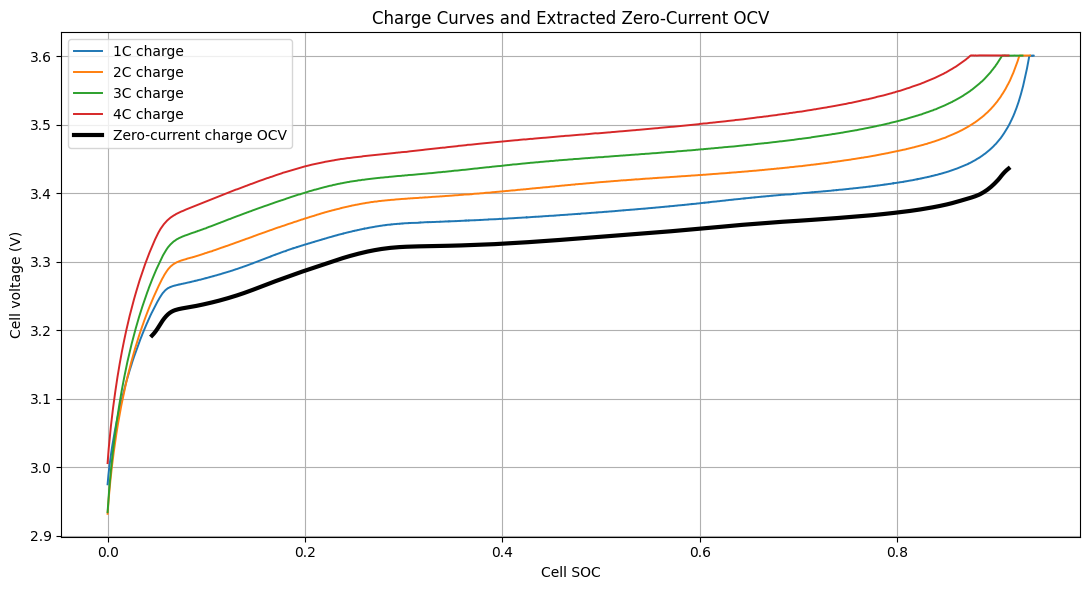

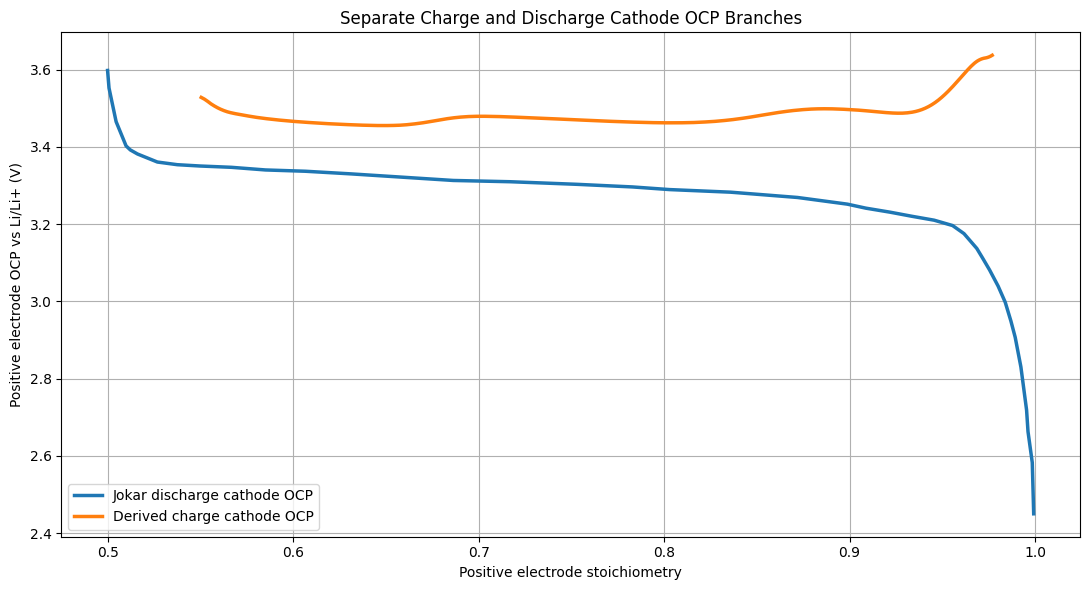

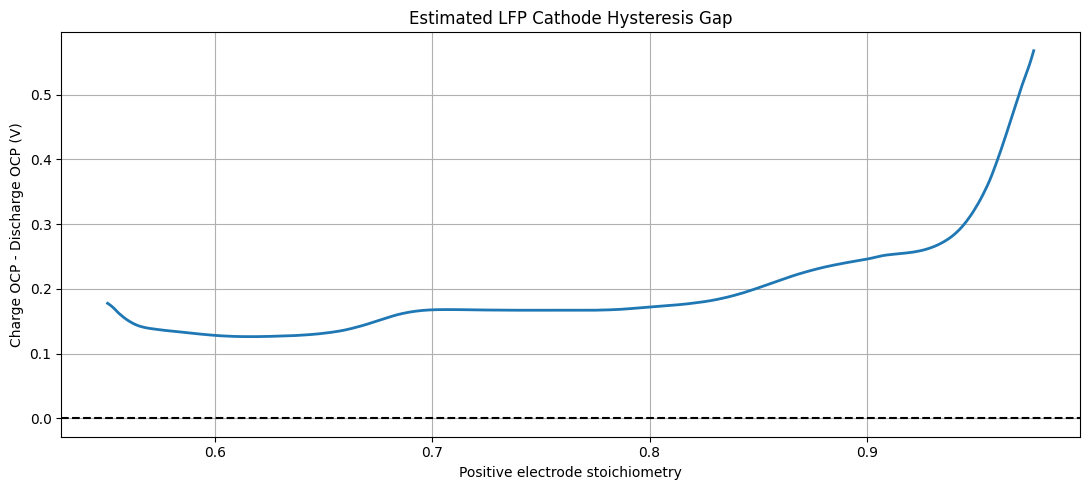

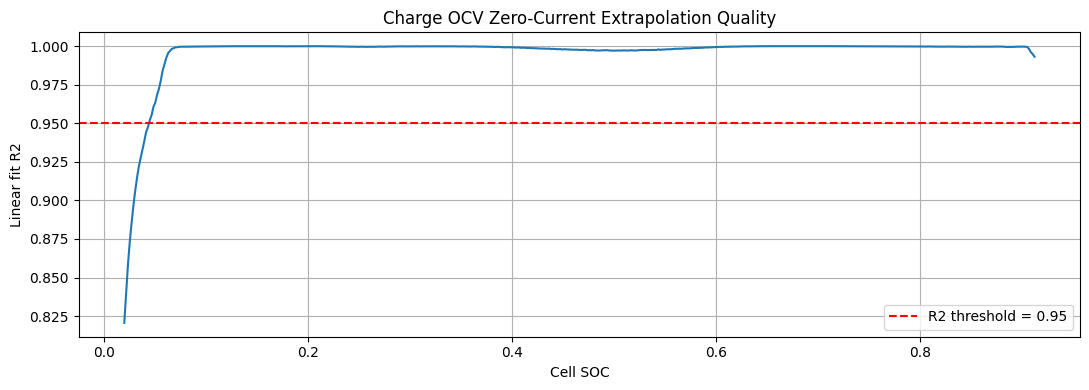

In [53]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator

# =====================================================
# USER SETTINGS
# =====================================================

cell_capacity_ah = 2.5

charge_files = {
    1.0: "Charge_1C_9330.mat",
    2.0: "Charge_2C_8642.mat",
    3.0: "Charge_3C_1216.mat",
    4.0: "Charge_4C_1562.mat"
}

# Full-cell SOC to electrode-stoichiometry mapping
theta_n_soc_0 = 0.05
theta_n_soc_1 = 0.905

theta_p_soc_0 = 0.999
theta_p_soc_1 = 0.5075

# Common SOC and quality limits
soc_minimum = 0.02
soc_maximum = 0.98
number_of_soc_points = 500

minimum_current_fraction = 0.70
minimum_r_squared = 0.95

# Smoothing window for extracted charging OCV
# Use 1 to disable smoothing
smoothing_window = 9

# =====================================================
# HELPER: LOAD CHARGE FILE
# =====================================================

def load_charge_file(filename):

    mat_data = loadmat(
        filename,
        squeeze_me=True,
        struct_as_record=False
    )

    if "meas" in mat_data:

        meas = mat_data["meas"]

        time = np.asarray(
            meas.Time,
            dtype=float
        ).reshape(-1)

        current = np.asarray(
            meas.Current,
            dtype=float
        ).reshape(-1)

        voltage = np.asarray(
            meas.Voltage,
            dtype=float
        ).reshape(-1)

    else:

        time = np.asarray(
            mat_data["Time"],
            dtype=float
        ).reshape(-1)

        current = np.asarray(
            mat_data["Current"],
            dtype=float
        ).reshape(-1)

        voltage = np.asarray(
            mat_data["Voltage"],
            dtype=float
        ).reshape(-1)

    number_of_points = min(
        len(time),
        len(current),
        len(voltage)
    )

    time = time[:number_of_points]
    current = current[:number_of_points]
    voltage = voltage[:number_of_points]

    finite_mask = (
        np.isfinite(time)
        & np.isfinite(current)
        & np.isfinite(voltage)
    )

    time = time[finite_mask]
    current = current[finite_mask]
    voltage = voltage[finite_mask]

    time = time - time[0]

    # Sort by time
    order = np.argsort(
        time,
        kind="stable"
    )

    time = time[order]
    current = current[order]
    voltage = voltage[order]

    # Keep final sample at duplicated timestamps
    _, reverse_index = np.unique(
        time[::-1],
        return_index=True
    )

    last_index = (
        len(time)
        - 1
        - reverse_index
    )

    last_index = np.sort(last_index)

    time = time[last_index]
    current = current[last_index]
    voltage = voltage[last_index]

    # Final strictly-increasing filter
    strict_mask = np.concatenate((
        [True],
        np.diff(time) > 0
    ))

    time = time[strict_mask]
    current = current[strict_mask]
    voltage = voltage[strict_mask]

    if len(time) < 2:

        raise ValueError(
            f"{filename} contains fewer than two unique timestamps."
        )

    return time, current, voltage

# =====================================================
# HELPER: SMOOTH CURVE
# =====================================================

def smooth_curve(values, window):

    values = np.asarray(
        values,
        dtype=float
    )

    if window <= 1:

        return values.copy()

    if window % 2 == 0:

        window += 1

    padding = window // 2

    padded_values = np.pad(
        values,
        pad_width=padding,
        mode="edge"
    )

    kernel = np.ones(window) / window

    return np.convolve(
        padded_values,
        kernel,
        mode="valid"
    )

# =====================================================
# LOAD AND PROCESS CHARGE DATA
# =====================================================

charge_data = {}

for nominal_c_rate, filename in charge_files.items():

    time, current, voltage = load_charge_file(
        filename
    )

    current_magnitude = np.abs(current)

    nominal_current = (
        nominal_c_rate
        * cell_capacity_ah
    )

    # Select approximately constant-current charge region
    cc_mask = (
        current_magnitude
        >= minimum_current_fraction
        * nominal_current
    )

    if np.sum(cc_mask) < 5:

        raise ValueError(
            f"Not enough constant-current samples in {filename}."
        )

    time_cc = time[cc_mask]
    current_cc = current_magnitude[cc_mask]
    voltage_cc = voltage[cc_mask]

    time_cc = time_cc - time_cc[0]

    charged_ah = cumulative_trapezoid(
        current_cc,
        time_cc,
        initial=0.0
    ) / 3600.0

    soc = charged_ah / cell_capacity_ah

    valid_mask = (
        (soc >= 0.0)
        & (soc <= 1.0)
        & np.isfinite(soc)
        & np.isfinite(current_cc)
        & np.isfinite(voltage_cc)
    )

    soc = soc[valid_mask]
    time_cc = time_cc[valid_mask]
    current_cc = current_cc[valid_mask]
    voltage_cc = voltage_cc[valid_mask]

    # Remove duplicated SOC entries
    soc_unique, unique_index = np.unique(
        soc,
        return_index=True
    )

    time_unique = time_cc[unique_index]
    current_unique = current_cc[unique_index]
    voltage_unique = voltage_cc[unique_index]

    charge_data[nominal_c_rate] = {
        "filename": filename,
        "time": time_unique,
        "soc": soc_unique,
        "current": current_unique,
        "voltage": voltage_unique
    }

    print(
        f"{nominal_c_rate:.0f}C: "
        f"{len(soc_unique)} points, "
        f"SOC {soc_unique.min():.4f} to "
        f"{soc_unique.max():.4f}, "
        f"current {current_unique.min():.3f} to "
        f"{current_unique.max():.3f} A"
    )

# =====================================================
# COMMON SOC RANGE
# =====================================================

common_soc_min = max(
    soc_minimum,
    max(
        dataset["soc"].min()
        for dataset in charge_data.values()
    )
)

common_soc_max = min(
    soc_maximum,
    min(
        dataset["soc"].max()
        for dataset in charge_data.values()
    )
)

if common_soc_max <= common_soc_min:

    raise ValueError(
        "No common SOC interval exists across all charge files."
    )

soc_common = np.linspace(
    common_soc_min,
    common_soc_max,
    number_of_soc_points
)

print()
print(
    "Common SOC range:",
    common_soc_min,
    "to",
    common_soc_max
)

# =====================================================
# INTERPOLATE ALL CHARGE CURVES TO COMMON SOC
# =====================================================

c_rates = np.array(
    sorted(charge_data.keys()),
    dtype=float
)

voltage_matrix = []
current_matrix = []

for c_rate in c_rates:

    dataset = charge_data[c_rate]

    voltage_interpolator = PchipInterpolator(
        dataset["soc"],
        dataset["voltage"],
        extrapolate=False
    )

    current_interpolator = PchipInterpolator(
        dataset["soc"],
        dataset["current"],
        extrapolate=False
    )

    voltage_matrix.append(
        voltage_interpolator(
            soc_common
        )
    )

    current_matrix.append(
        current_interpolator(
            soc_common
        )
    )

voltage_matrix = np.asarray(
    voltage_matrix
)

current_matrix = np.asarray(
    current_matrix
)

# =====================================================
# ZERO-CURRENT CHARGE OCV EXTRAPOLATION
# =====================================================

charge_cell_ocv_raw = np.full(
    len(soc_common),
    np.nan
)

polarization_slope = np.full(
    len(soc_common),
    np.nan
)

fit_r_squared = np.full(
    len(soc_common),
    np.nan
)

for index in range(len(soc_common)):

    current_at_soc = current_matrix[:, index]
    voltage_at_soc = voltage_matrix[:, index]

    valid = (
        np.isfinite(current_at_soc)
        & np.isfinite(voltage_at_soc)
    )

    current_at_soc = current_at_soc[valid]
    voltage_at_soc = voltage_at_soc[valid]

    if len(current_at_soc) < 2:

        continue

    slope, intercept = np.polyfit(
        current_at_soc,
        voltage_at_soc,
        1
    )

    voltage_fit = (
        slope * current_at_soc
        + intercept
    )

    residual_sum = np.sum(
        (
            voltage_at_soc
            - voltage_fit
        ) ** 2
    )

    total_sum = np.sum(
        (
            voltage_at_soc
            - np.mean(voltage_at_soc)
        ) ** 2
    )

    charge_cell_ocv_raw[index] = intercept
    polarization_slope[index] = slope

    if total_sum > 0:

        fit_r_squared[index] = (
            1.0
            - residual_sum / total_sum
        )

# =====================================================
# FILTER CHARGE OCV BY FIT QUALITY
# =====================================================

quality_mask = (
    np.isfinite(charge_cell_ocv_raw)
    & np.isfinite(fit_r_squared)
    & (fit_r_squared >= minimum_r_squared)
)

soc_charge_valid = soc_common[quality_mask]

charge_cell_ocv_valid = charge_cell_ocv_raw[
    quality_mask
]

charge_fit_r_squared = fit_r_squared[
    quality_mask
]

if len(soc_charge_valid) < 4:

    raise ValueError(
        "Too few valid charging OCV points remain after R2 filtering."
    )

charge_cell_ocv_smooth = smooth_curve(
    charge_cell_ocv_valid,
    smoothing_window
)

# =====================================================
# PRADA GRAPHITE ANODE OCP
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

graphite_ocp_function = params[
    "Negative electrode OCP [V]"
]

theta_n_charge = (
    theta_n_soc_0
    + soc_charge_valid
    * (
        theta_n_soc_1
        - theta_n_soc_0
    )
)

theta_p_charge = (
    theta_p_soc_0
    + soc_charge_valid
    * (
        theta_p_soc_1
        - theta_p_soc_0
    )
)

graphite_ocp_charge = np.array([
    float(
        graphite_ocp_function(
            pybamm.Scalar(theta)
        ).evaluate()
    )
    for theta in theta_n_charge
])

# =====================================================
# DERIVE CHARGING CATHODE OCP
#
# U_cell = U_positive - U_negative
# U_positive = U_cell + U_negative
# =====================================================

charge_cathode_ocp = (
    charge_cell_ocv_smooth
    + graphite_ocp_charge
)

# Sort by positive-electrode stoichiometry
charge_order = np.argsort(
    theta_p_charge
)

theta_p_charge = theta_p_charge[
    charge_order
]

charge_cathode_ocp = charge_cathode_ocp[
    charge_order
]

# Remove duplicate positive stoichiometries
theta_p_charge, charge_unique_index = np.unique(
    theta_p_charge,
    return_index=True
)

charge_cathode_ocp = charge_cathode_ocp[
    charge_unique_index
]

# =====================================================
# JOKAR DISCHARGE CATHODE OCP
# =====================================================

jokar_raw_axis = np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
])

theta_p_discharge = (
    (1.0 - aa)
    + aa * (
        1.0 - jokar_raw_axis
    )
)

discharge_cathode_ocp = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

discharge_order = np.argsort(
    theta_p_discharge
)

theta_p_discharge = theta_p_discharge[
    discharge_order
]

discharge_cathode_ocp = discharge_cathode_ocp[
    discharge_order
]

discharge_keep = np.concatenate((
    [True],
    np.diff(theta_p_discharge) > 1e-6
))

theta_p_discharge = theta_p_discharge[
    discharge_keep
]

discharge_cathode_ocp = discharge_cathode_ocp[
    discharge_keep
]

# =====================================================
# CREATE SCIPY INTERPOLATION FUNCTIONS
# =====================================================

charge_ocp_interpolator = PchipInterpolator(
    theta_p_charge,
    charge_cathode_ocp,
    extrapolate=False
)

discharge_ocp_interpolator = PchipInterpolator(
    theta_p_discharge,
    discharge_cathode_ocp,
    extrapolate=False
)

# =====================================================
# CREATE PYBAMM-READY EXTENDED LOOKUP TABLES
# =====================================================

theta_full = np.linspace(
    0.0,
    1.0,
    1000
)

charge_ocp_full = np.interp(
    theta_full,
    theta_p_charge,
    charge_cathode_ocp,
    left=charge_cathode_ocp[0],
    right=charge_cathode_ocp[-1]
)

discharge_ocp_full = np.interp(
    theta_full,
    theta_p_discharge,
    discharge_cathode_ocp,
    left=discharge_cathode_ocp[0],
    right=discharge_cathode_ocp[-1]
)

def positive_ocp_charge(sto):

    return pybamm.Interpolant(
        theta_full,
        charge_ocp_full,
        sto,
        interpolator="linear"
    )

def positive_ocp_discharge(sto):

    return pybamm.Interpolant(
        theta_full,
        discharge_ocp_full,
        sto,
        interpolator="linear"
    )

# =====================================================
# COMMON RANGE FOR BRANCH COMPARISON
# =====================================================

theta_common_min = max(
    theta_p_charge.min(),
    theta_p_discharge.min()
)

theta_common_max = min(
    theta_p_charge.max(),
    theta_p_discharge.max()
)

theta_common = np.linspace(
    theta_common_min,
    theta_common_max,
    400
)

charge_common = charge_ocp_interpolator(
    theta_common
)

discharge_common = discharge_ocp_interpolator(
    theta_common
)

hysteresis_gap = (
    charge_common
    - discharge_common
)

# =====================================================
# SUMMARY
# =====================================================

print()
print("================================")
print("SEPARATE CATHODE OCP BRANCHES")
print("================================")
print(
    "Valid charging SOC range       :",
    soc_charge_valid.min(),
    "to",
    soc_charge_valid.max()
)
print(
    "Number of charge OCP points    :",
    len(theta_p_charge)
)
print(
    "Number of discharge OCP points :",
    len(theta_p_discharge)
)
print(
    "Mean accepted charge fit R2     :",
    np.mean(charge_fit_r_squared)
)
print(
    "Minimum accepted charge fit R2  :",
    np.min(charge_fit_r_squared)
)
print(
    "Charge cathode OCP range (V)    :",
    charge_cathode_ocp.min(),
    "to",
    charge_cathode_ocp.max()
)
print(
    "Discharge cathode OCP range (V) :",
    discharge_cathode_ocp.min(),
    "to",
    discharge_cathode_ocp.max()
)
print(
    "Mean hysteresis gap (V)         :",
    np.mean(hysteresis_gap)
)
print(
    "Minimum hysteresis gap (V)      :",
    np.min(hysteresis_gap)
)
print(
    "Maximum hysteresis gap (V)      :",
    np.max(hysteresis_gap)
)

# =====================================================
# PLOT CHARGE-RATE CURVES AND EXTRACTED CELL OCV
# =====================================================

plt.figure(
    figsize=(11, 6)
)

for c_rate in c_rates:

    dataset = charge_data[c_rate]

    plt.plot(
        dataset["soc"],
        dataset["voltage"],
        linewidth=1.4,
        label=f"{c_rate:.0f}C charge"
    )

plt.plot(
    soc_charge_valid,
    charge_cell_ocv_smooth,
    color="black",
    linewidth=3,
    label="Zero-current charge OCV"
)

plt.xlabel("Cell SOC")
plt.ylabel("Cell voltage (V)")
plt.title(
    "Charge Curves and Extracted Zero-Current OCV"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT CHARGE AND DISCHARGE CATHODE OCP
# =====================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    theta_p_discharge,
    discharge_cathode_ocp,
    linewidth=2.5,
    label="Jokar discharge cathode OCP"
)

plt.plot(
    theta_p_charge,
    charge_cathode_ocp,
    linewidth=2.5,
    label="Derived charge cathode OCP"
)

plt.xlabel(
    "Positive electrode stoichiometry"
)

plt.ylabel(
    "Positive electrode OCP vs Li/Li+ (V)"
)

plt.title(
    "Separate Charge and Discharge Cathode OCP Branches"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT HYSTERESIS GAP
# =====================================================

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    theta_common,
    hysteresis_gap,
    linewidth=2
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--"
)

plt.xlabel(
    "Positive electrode stoichiometry"
)

plt.ylabel(
    "Charge OCP - Discharge OCP (V)"
)

plt.title(
    "Estimated LFP Cathode Hysteresis Gap"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# PLOT ZERO-CURRENT FIT QUALITY
# =====================================================

plt.figure(
    figsize=(11, 4)
)

plt.plot(
    soc_common,
    fit_r_squared,
    linewidth=1.5
)

plt.axhline(
    minimum_r_squared,
    color="red",
    linestyle="--",
    label=f"R2 threshold = {minimum_r_squared}"
)

plt.xlabel("Cell SOC")
plt.ylabel("Linear fit R2")
plt.title(
    "Charge OCV Zero-Current Extrapolation Quality"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Clean HPPC samples : 6996
HPPC duration (s)  : 8991.105999425054
Strict increase    : True
Measured current   : -37.4989 to 9.9996 A
PyBaMM current     : -9.9996 to 37.4989 A
Hysteresis state range: 0.011865498049671208 to 0.9714615656899146

DFN WITH SHIFTED OCP HYSTERESIS
OCP shift (V)              : 0.06
Hysteresis transition Ah   : 0.03
Initial hysteresis state   : 0.5
Final hysteresis state     : 0.07856417916897285
Compared duration (s)      : 8991.105999425054
Compared samples           : 6996
Net discharge (Ah)         : 0.22711927949767566
Absolute throughput (Ah)   : 0.9902053180893883
Final coulomb SOC          : 0.9091522882009297

Overall RMSE (V)           : 0.04782204722833222
Overall MAE (V)            : 0.03289022895859737
Maximum error (V)          : 0.17315494268745235
Overall bias (V)           : -0.02139624512129759

Rest RMSE / bias (V)       : 0.043781021621860323 / -0.02396417134862317
Discharge RMSE / bias (V)  : 0.05032586103615637 / 0.028956269982172864
Charg

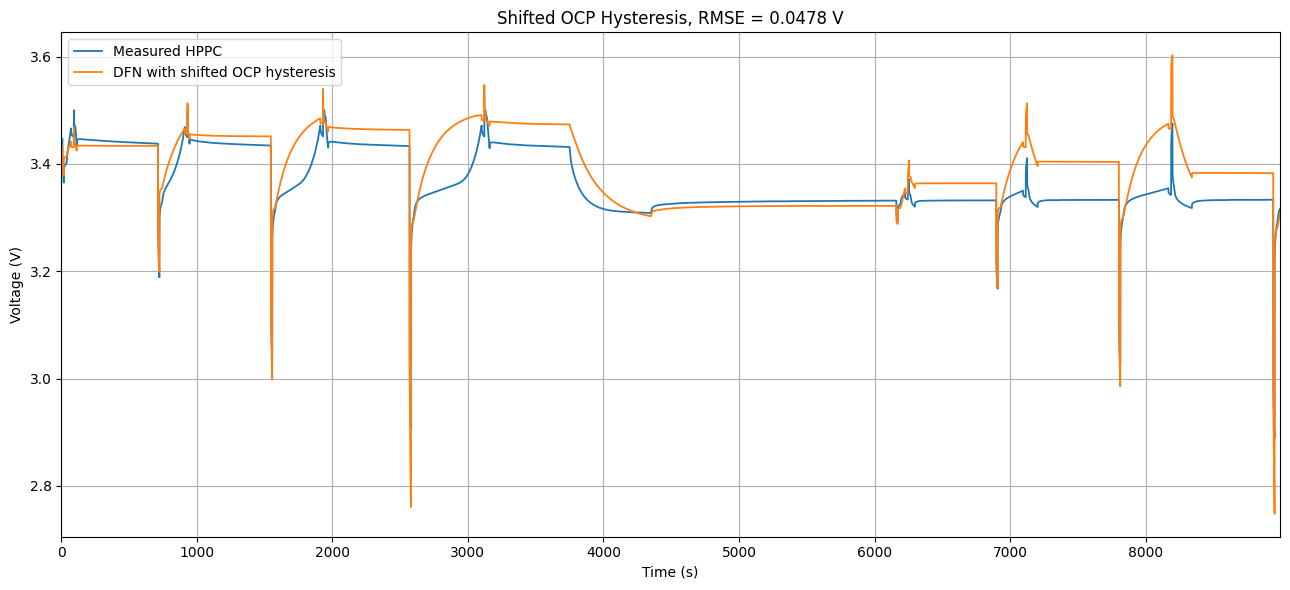

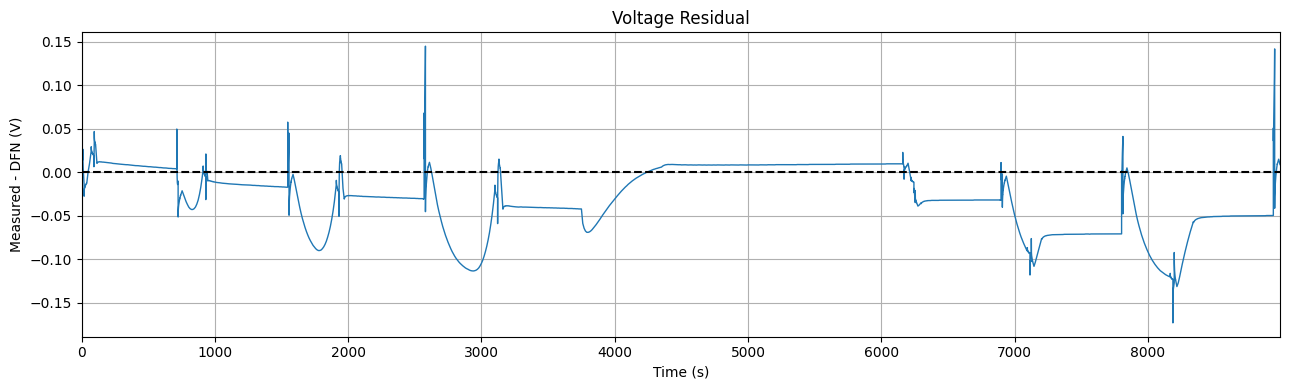

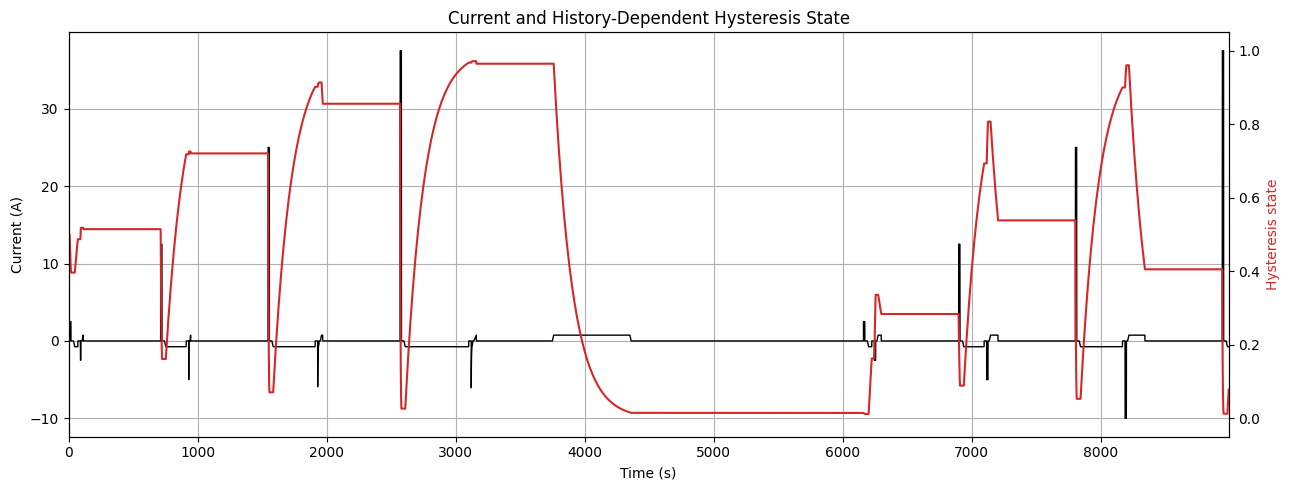

In [59]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# CHECK REQUIRED OCP ARRAYS
# =====================================================

required_names = [
    "theta_full",
    "charge_ocp_full",
    "discharge_ocp_full"
]

for name in required_names:
    if name not in globals():
        raise NameError(
            f"{name} is not defined. "
            "Run the charge/discharge OCP extraction cell first."
        )

theta_full = np.asarray(theta_full, dtype=float).reshape(-1)
charge_ocp_full = np.asarray(
    charge_ocp_full,
    dtype=float
).reshape(-1)

discharge_ocp_full = np.asarray(
    discharge_ocp_full,
    dtype=float
).reshape(-1)

if not (
    len(theta_full)
    == len(charge_ocp_full)
    == len(discharge_ocp_full)
):
    raise ValueError(
        "theta_full, charge_ocp_full, and discharge_ocp_full "
        "must have identical lengths."
    )

if not np.all(np.diff(theta_full) > 0):
    raise ValueError(
        "theta_full must be strictly increasing."
    )

# =====================================================
# USER SETTINGS
# =====================================================

hppc_filename = "HPPC_5458.mat"
t_compare = 9000.0

nominal_capacity_ah = 2.5

theta_n_init = 0.905
theta_p_init = 0.5075

negative_thickness = 129e-6
positive_thickness = 171e-6
positive_active_fraction = 0.55

positive_particle_radius = 2.5e-6
positive_diffusivity = 1.0e-13

contact_resistance = 0.0

positive_kinetic_multiplier = 30.0
negative_kinetic_multiplier = 30.0

electrolyte_conductivity_multiplier = 1.6
electrolyte_diffusivity_multiplier = 1.0

# =====================================================
# OCP SHIFT
# =====================================================

ocp_shift_ch = 0.04
ocp_shift_di = 0.05

charge_ocp_shifted = (
    charge_ocp_full
    + ocp_shift_ch
)

discharge_ocp_shifted = (
    discharge_ocp_full
    + ocp_shift_di
)

# =====================================================
# HYSTERESIS SETTINGS
# =====================================================

# h = 0 means discharge branch
# h = 1 means charge branch

initial_hysteresis_state = 0.50

# Freeze the state when current magnitude is below this value.
hysteresis_current_deadband = 0.05

# Smaller value means faster branch switching.
# Larger value means stronger memory.
hysteresis_transition_ah = 0.03

# =====================================================
# METRIC THRESHOLDS
# =====================================================

rest_current_threshold = 0.05
discharge_pulse_threshold = 5.0
charge_pulse_threshold = 1.0

# =====================================================
# LOAD HPPC DATA
# =====================================================

hppc_data = loadmat(
    hppc_filename,
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(
    meas.Time,
    dtype=float
).reshape(-1)

current_raw = np.asarray(
    meas.Current,
    dtype=float
).reshape(-1)

voltage_raw = np.asarray(
    meas.Voltage,
    dtype=float
).reshape(-1)

# Keep common length
number_raw = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:number_raw]
current_raw = current_raw[:number_raw]
voltage_raw = voltage_raw[:number_raw]

# Remove invalid samples
finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

# Shift time to zero
time_raw = time_raw - time_raw[0]

# Restrict duration
duration_mask = (
    (time_raw >= 0.0)
    & (time_raw <= t_compare)
)

time_raw = time_raw[duration_mask]
current_raw = current_raw[duration_mask]
voltage_raw = voltage_raw[duration_mask]

# =====================================================
# SORT AND REMOVE DUPLICATE TIMES
# =====================================================

time_order = np.argsort(
    time_raw,
    kind="stable"
)

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final sample at each duplicate timestamp
_, reverse_unique_index = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_index = (
    len(time_sorted)
    - 1
    - reverse_unique_index
)

last_index = np.sort(last_index)

time_exp = time_sorted[last_index]
current_measured = current_sorted[last_index]
voltage_exp = voltage_sorted[last_index]

# Final strictly increasing filter
strict_mask = np.concatenate(
    ([True], np.diff(time_exp) > 0.0)
)

time_exp = time_exp[strict_mask]
current_measured = current_measured[strict_mask]
voltage_exp = voltage_exp[strict_mask]

if len(time_exp) < 2:
    raise ValueError(
        "Fewer than two unique HPPC timestamps remain."
    )

if not np.all(np.diff(time_exp) > 0.0):
    raise ValueError(
        "The cleaned HPPC time vector is not strictly increasing."
    )

# PyBaMM sign convention:
# positive current = discharge
# negative current = charge
current_pybamm = -current_measured

print("Clean HPPC samples :", len(time_exp))
print("HPPC duration (s)  :", time_exp[-1])
print(
    "Strict increase    :",
    bool(np.all(np.diff(time_exp) > 0.0))
)
print(
    "Measured current   :",
    current_measured.min(),
    "to",
    current_measured.max(),
    "A"
)
print(
    "PyBaMM current     :",
    current_pybamm.min(),
    "to",
    current_pybamm.max(),
    "A"
)

# =====================================================
# CALCULATE HISTORY-DEPENDENT HYSTERESIS STATE
# =====================================================

hysteresis_state = np.zeros_like(
    time_exp,
    dtype=float
)

hysteresis_state[0] = np.clip(
    initial_hysteresis_state,
    0.0,
    1.0
)

for index in range(1, len(time_exp)):

    delta_time_seconds = (
        time_exp[index]
        - time_exp[index - 1]
    )

    current_value = current_pybamm[index - 1]

    previous_state = hysteresis_state[index - 1]

    if current_value > hysteresis_current_deadband:
        # Discharge
        target_state = 0.0

    elif current_value < -hysteresis_current_deadband:
        # Charge
        target_state = 1.0

    else:
        # Rest: retain branch memory
        target_state = previous_state

    current_magnitude = abs(current_value)

    delta_ah = (
        current_magnitude
        * delta_time_seconds
        / 3600.0
    )

    if current_magnitude <= hysteresis_current_deadband:
        transition_fraction = 0.0
    else:
        transition_fraction = (
            1.0
            - np.exp(
                -delta_ah
                / hysteresis_transition_ah
            )
        )

    hysteresis_state[index] = np.clip(
        previous_state
        + transition_fraction
        * (
            target_state
            - previous_state
        ),
        0.0,
        1.0
    )

print(
    "Hysteresis state range:",
    hysteresis_state.min(),
    "to",
    hysteresis_state.max()
)

# =====================================================
# TIME-DEPENDENT CURRENT AND HYSTERESIS INTERPOLANTS
# =====================================================

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

hysteresis_state_function = pybamm.Interpolant(
    time_exp,
    hysteresis_state,
    pybamm.t,
    interpolator="linear"
)

# =====================================================
# CHARGE AND DISCHARGE OCP BRANCHES
# =====================================================

def positive_ocp_charge_branch(sto):
    return pybamm.Interpolant(
        theta_full,
        charge_ocp_shifted,
        sto,
        interpolator="linear"
    )

def positive_ocp_discharge_branch(sto):
    return pybamm.Interpolant(
        theta_full,
        discharge_ocp_shifted,
        sto,
        interpolator="linear"
    )

# =====================================================
# HISTORY-DEPENDENT OCP
# =====================================================

def positive_ocp_with_hysteresis(sto):

    charge_branch = positive_ocp_charge_branch(
        sto
    )

    discharge_branch = positive_ocp_discharge_branch(
        sto
    )

    hysteresis_value = hysteresis_state_function

    return (
        hysteresis_value
        * charge_branch
        + (
            1.0
            - hysteresis_value
        )
        * discharge_branch
    )

# =====================================================
# BUILD PRADA2013 PARAMETER SET
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

# Store original functions before overriding them
original_positive_j0 = params[
    "Positive electrode exchange-current density [A.m-2]"
]

original_negative_j0 = params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_electrolyte_conductivity = params[
    "Electrolyte conductivity [S.m-1]"
]

original_electrolyte_diffusivity = params[
    "Electrolyte diffusivity [m2.s-1]"
]

# =====================================================
# SCALED ELECTRODE KINETICS
# =====================================================

def scaled_positive_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        positive_kinetic_multiplier
        * original_positive_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

def scaled_negative_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        negative_kinetic_multiplier
        * original_negative_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

# =====================================================
# SCALED ELECTROLYTE TRANSPORT
# =====================================================

def scaled_electrolyte_conductivity(
    c_e,
    temperature
):
    return (
        electrolyte_conductivity_multiplier
        * original_electrolyte_conductivity(
            c_e,
            temperature
        )
    )

def scaled_electrolyte_diffusivity(
    c_e,
    temperature
):
    return (
        electrolyte_diffusivity_multiplier
        * original_electrolyte_diffusivity(
            c_e,
            temperature
        )
    )

# =====================================================
# UPDATE PARAMETERS
# =====================================================

params.update({
    "Nominal cell capacity [A.h]":
        nominal_capacity_ah,

    "Positive electrode OCP [V]":
        positive_ocp_with_hysteresis,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        negative_thickness,

    "Positive electrode thickness [m]":
        positive_thickness,

    "Positive electrode active material volume fraction":
        positive_active_fraction,

    "Positive particle radius [m]":
        positive_particle_radius,

    "Positive electrode diffusivity [m2.s-1]":
        positive_diffusivity,

    "Positive electrode exchange-current density [A.m-2]":
        scaled_positive_exchange_current_density,

    "Negative electrode exchange-current density [A.m-2]":
        scaled_negative_exchange_current_density,

    "Electrolyte conductivity [S.m-1]":
        scaled_electrolyte_conductivity,

    "Electrolyte diffusivity [m2.s-1]":
        scaled_electrolyte_diffusivity,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        contact_resistance
})

# =====================================================
# BUILD AND RUN DFN
# =====================================================

model = pybamm.lithium_ion.DFN(
    options={
        "contact resistance": "true"
    }
)

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver
)

solution = simulation.solve(
    t_eval=time_exp
)

time_model = np.asarray(
    solution["Time [s]"].entries,
    dtype=float
).reshape(-1)

voltage_model = np.asarray(
    solution["Terminal voltage [V]"].entries,
    dtype=float
).reshape(-1)

if len(time_model) < 2:
    raise RuntimeError(
        "DFN returned fewer than two time points."
    )

# =====================================================
# VALID COMPARISON WINDOW
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1]),
    t_compare
)

valid_mask = time_exp <= t_valid_end

time_valid = time_exp[valid_mask]

current_measured_valid = current_measured[
    valid_mask
]

current_pybamm_valid = current_pybamm[
    valid_mask
]

voltage_measured_valid = voltage_exp[
    valid_mask
]

hysteresis_valid = hysteresis_state[
    valid_mask
]

voltage_simulated_valid = np.interp(
    time_valid,
    time_model,
    voltage_model
)

voltage_error = (
    voltage_measured_valid
    - voltage_simulated_valid
)

# =====================================================
# OVERALL METRICS
# =====================================================

overall_rmse = float(
    np.sqrt(
        np.mean(
            voltage_error ** 2
        )
    )
)

overall_mae = float(
    np.mean(
        np.abs(
            voltage_error
        )
    )
)

maximum_error = float(
    np.max(
        np.abs(
            voltage_error
        )
    )
)

overall_bias = float(
    np.mean(
        voltage_error
    )
)

# =====================================================
# DIRECTIONAL METRICS
# =====================================================

rest_mask = (
    np.abs(current_pybamm_valid)
    < rest_current_threshold
)

discharge_pulse_mask = (
    current_pybamm_valid
    > discharge_pulse_threshold
)

charge_pulse_mask = (
    current_pybamm_valid
    < -charge_pulse_threshold
)

intermediate_mask = (
    ~rest_mask
    & ~discharge_pulse_mask
    & ~charge_pulse_mask
)

def masked_rmse(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.sqrt(
            np.mean(
                voltage_error[mask] ** 2
            )
        )
    )

def masked_bias(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.mean(
            voltage_error[mask]
        )
    )

rest_rmse = masked_rmse(
    rest_mask
)

rest_bias = masked_bias(
    rest_mask
)

discharge_pulse_rmse = masked_rmse(
    discharge_pulse_mask
)

discharge_pulse_bias = masked_bias(
    discharge_pulse_mask
)

charge_pulse_rmse = masked_rmse(
    charge_pulse_mask
)

charge_pulse_bias = masked_bias(
    charge_pulse_mask
)

intermediate_rmse = masked_rmse(
    intermediate_mask
)

intermediate_bias = masked_bias(
    intermediate_mask
)

# =====================================================
# CAPACITY THROUGHPUT
# =====================================================

integrator = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

net_discharge_ah = float(
    integrator(
        current_pybamm_valid,
        time_valid
    ) / 3600.0
)

absolute_throughput_ah = float(
    integrator(
        np.abs(
            current_pybamm_valid
        ),
        time_valid
    ) / 3600.0
)

final_coulomb_soc = (
    1.0
    - net_discharge_ah
    / nominal_capacity_ah
)

# =====================================================
# PRINT RESULTS
# =====================================================

print()
print("============================================")
print("DFN WITH SHIFTED OCP HYSTERESIS")
print("============================================")
print(
    "OCP shift (V)              :",
    ocp_shift
)
print(
    "Hysteresis transition Ah   :",
    hysteresis_transition_ah
)
print(
    "Initial hysteresis state   :",
    initial_hysteresis_state
)
print(
    "Final hysteresis state     :",
    hysteresis_valid[-1]
)
print(
    "Compared duration (s)      :",
    t_valid_end
)
print(
    "Compared samples           :",
    len(time_valid)
)
print(
    "Net discharge (Ah)         :",
    net_discharge_ah
)
print(
    "Absolute throughput (Ah)   :",
    absolute_throughput_ah
)
print(
    "Final coulomb SOC          :",
    final_coulomb_soc
)

print()
print(
    "Overall RMSE (V)           :",
    overall_rmse
)
print(
    "Overall MAE (V)            :",
    overall_mae
)
print(
    "Maximum error (V)          :",
    maximum_error
)
print(
    "Overall bias (V)           :",
    overall_bias
)

print()
print(
    "Rest RMSE / bias (V)       :",
    rest_rmse,
    "/",
    rest_bias
)
print(
    "Discharge RMSE / bias (V)  :",
    discharge_pulse_rmse,
    "/",
    discharge_pulse_bias
)
print(
    "Charge RMSE / bias (V)     :",
    charge_pulse_rmse,
    "/",
    charge_pulse_bias
)
print(
    "Intermediate RMSE/bias (V) :",
    intermediate_rmse,
    "/",
    intermediate_bias
)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    time_valid,
    voltage_measured_valid,
    linewidth=1.3,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.3,
    label="DFN with shifted OCP hysteresis"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Voltage (V)"
)

plt.title(
    f"Shifted OCP Hysteresis, "
    f"RMSE = {overall_rmse:.4f} V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(
    figsize=(13, 4)
)

plt.plot(
    time_valid,
    voltage_error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Measured - DFN (V)"
)

plt.title(
    "Voltage Residual"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# CURRENT AND HYSTERESIS STATE
# =====================================================

figure, current_axis = plt.subplots(
    figsize=(13, 5)
)

current_axis.plot(
    time_valid,
    current_pybamm_valid,
    color="black",
    linewidth=1.0,
    label="PyBaMM current"
)

current_axis.set_xlim(
    0,
    t_valid_end
)

current_axis.set_xlabel(
    "Time (s)"
)

current_axis.set_ylabel(
    "Current (A)",
    color="black"
)

current_axis.grid(True)

hysteresis_axis = current_axis.twinx()

hysteresis_axis.plot(
    time_valid,
    hysteresis_valid,
    color="tab:red",
    linewidth=1.5,
    label="Hysteresis state"
)

hysteresis_axis.set_ylabel(
    "Hysteresis state",
    color="tab:red"
)

hysteresis_axis.set_ylim(
    -0.05,
    1.05
)

plt.title(
    "Current and History-Dependent Hysteresis State"
)

figure.tight_layout()
plt.show()

In [60]:
temperature = np.asarray(
    meas.Battery_Temp_degC,
    dtype=float
).reshape(-1)

print(
    "Temperature range:",
    np.nanmin(temperature),
    "to",
    np.nanmax(temperature),
    "degC"
)

Temperature range: 22.8357 to 24.0985 degC


In [ ]:
#dome shaped charging profile is not captured, keeping single ocp curve

Clean HPPC samples : 6996
HPPC duration (s)  : 8991.105999425054
Strict increase    : True
Measured current   : -37.4989 to 9.9996 A
PyBaMM current     : -9.9996 to 37.4989 A

Fast hysteresis range : 1.8220911898036818e-06 to 0.9999748117248599
Slow hysteresis range : 0.24854029910735692 to 0.6473636493379348
Total hysteresis range: 0.1660228132315049 to 0.7707775561733585

DFN WITH TWO-TIMESCALE OCP HYSTERESIS
Temperature (K)             : 296.62
Charge OCP shift (V)        : 0.0
Discharge OCP shift (V)     : 0.06
Fast transition (Ah)        : 0.01
Slow transition (Ah)        : 0.15
Fast-state weight           : 0.35
Initial combined state      : 0.5
Final combined state        : 0.23828764575362751
Compared duration (s)       : 8991.105999425054
Compared samples            : 6996
Net discharge (Ah)          : 0.22711927949767566
Absolute throughput (Ah)    : 0.9902053180893883
Final coulomb SOC           : 0.9091522882009297

Overall RMSE (V)            : 0.03819427577637727
Overall 

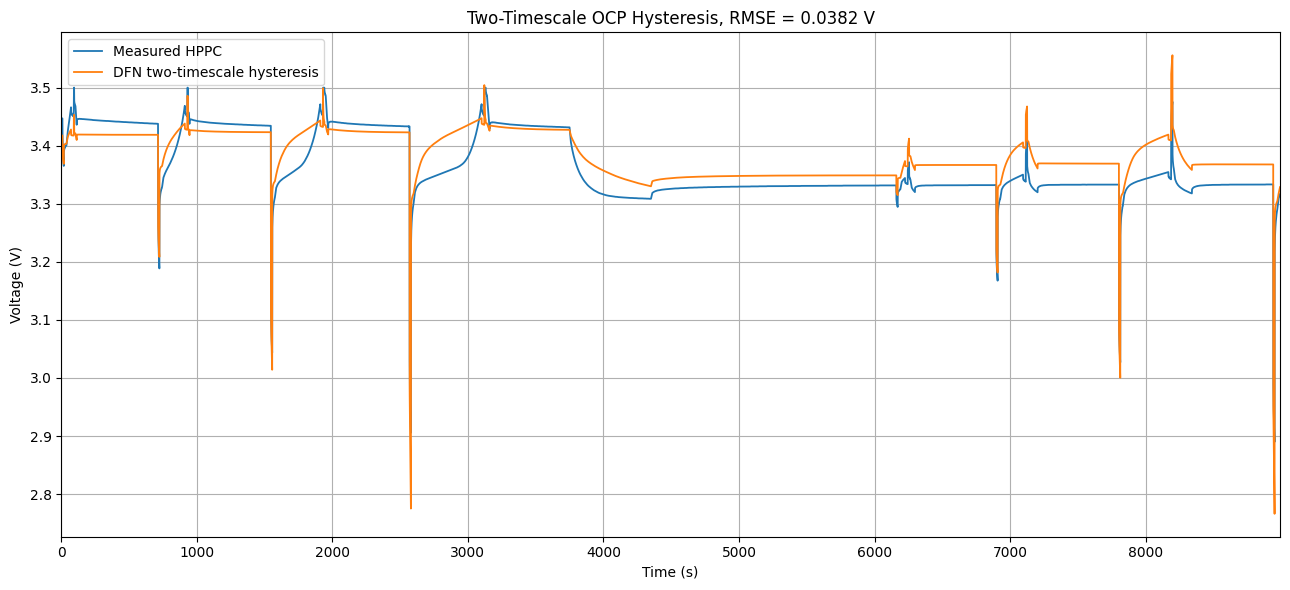

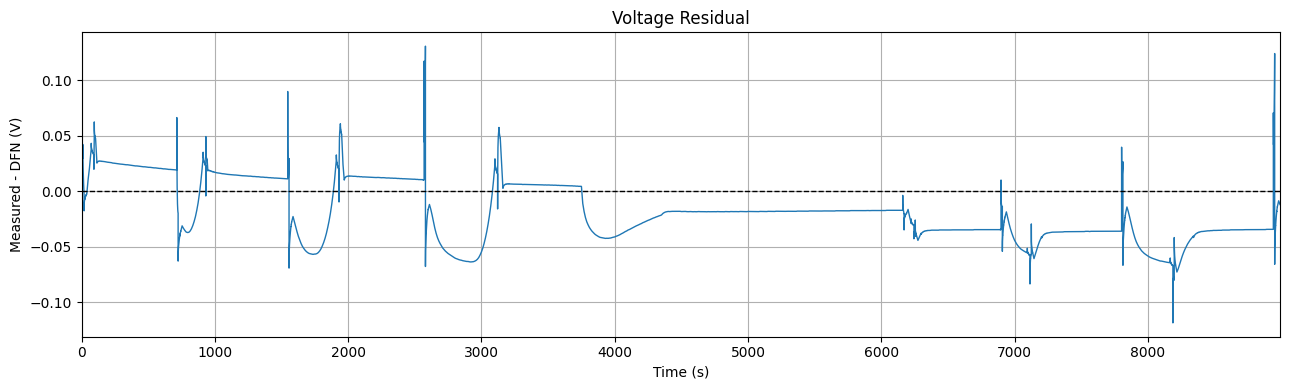

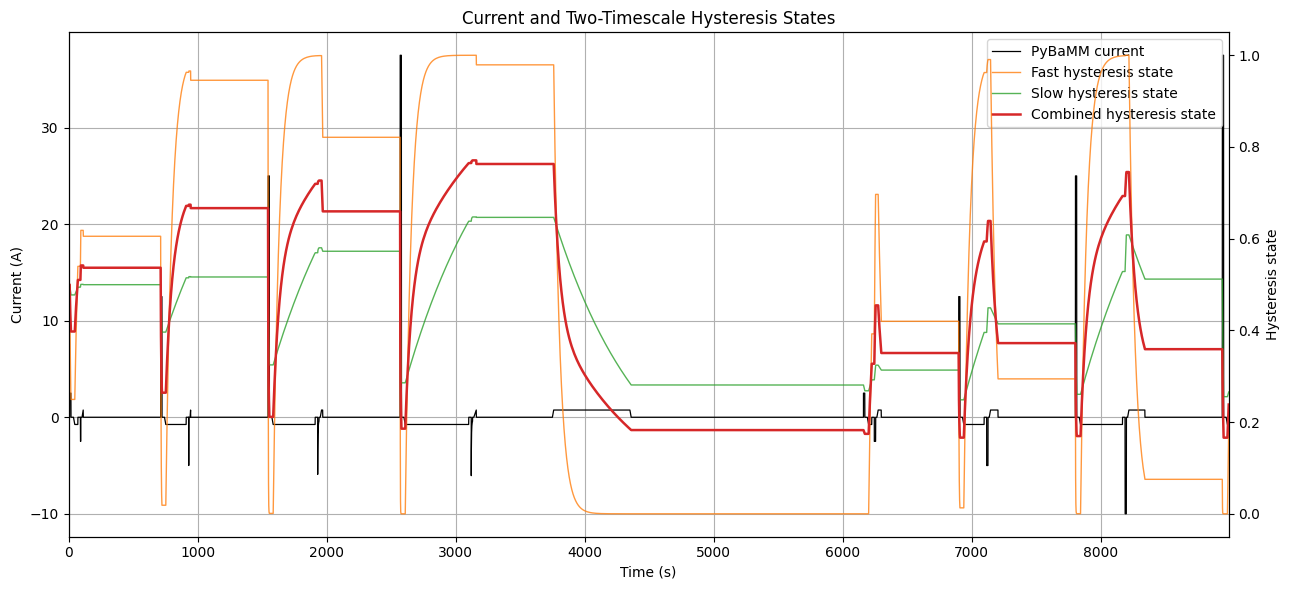

In [61]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# REQUIRED OCP ARRAYS FROM THE EXTRACTION CELL
# =====================================================

required_arrays = [
    "theta_full",
    "charge_ocp_full",
    "discharge_ocp_full"
]

for required_name in required_arrays:
    if required_name not in globals():
        raise NameError(
            f"{required_name} is not defined. "
            "Run the charge/discharge OCP extraction cell first."
        )

theta_full = np.asarray(
    theta_full,
    dtype=float
).reshape(-1)

charge_ocp_base = np.asarray(
    charge_ocp_full,
    dtype=float
).reshape(-1)

discharge_ocp_base = np.asarray(
    discharge_ocp_full,
    dtype=float
).reshape(-1)

if not (
    len(theta_full)
    == len(charge_ocp_base)
    == len(discharge_ocp_base)
):
    raise ValueError(
        "theta_full, charge_ocp_full, and discharge_ocp_full "
        "must have the same length."
    )

if not np.all(np.diff(theta_full) > 0.0):
    raise ValueError(
        "theta_full must be strictly increasing."
    )

# =====================================================
# USER SETTINGS
# =====================================================

hppc_filename = "HPPC_5458.mat"
t_compare = 9000.0

nominal_capacity_ah = 2.5

theta_n_init = 0.905
theta_p_init = 0.5075

negative_thickness = 129e-6
positive_thickness = 171e-6
positive_active_fraction = 0.55

positive_particle_radius = 2.5e-6
positive_diffusivity = 1.0e-13

positive_kinetic_multiplier = 30.0
negative_kinetic_multiplier = 30.0

electrolyte_conductivity_multiplier = 1.6
electrolyte_diffusivity_multiplier = 1.0

contact_resistance = 0.0

# Average measured temperature
model_temperature_kelvin = 296.62

# =====================================================
# OCP BRANCH SHIFTS
# =====================================================

# Start with the better-performing branch shifts.
# Change these only after hysteresis time scales are calibrated.

charge_ocp_shift = 0.00
discharge_ocp_shift = 0.06

charge_ocp_table = (
    charge_ocp_base
    + charge_ocp_shift
)

discharge_ocp_table = (
    discharge_ocp_base
    + discharge_ocp_shift
)

# =====================================================
# TWO-TIMESCALE HYSTERESIS SETTINGS
# =====================================================

# h = 0 means discharge branch
# h = 1 means charge branch

initial_fast_state = 0.50
initial_slow_state = 0.50

# Fast transition captures immediate branch movement.
fast_transition_ah = 0.01

# Slow transition captures the broad dome-shaped response.
slow_transition_ah = 0.15

# Total state:
# h_total = fast_weight*h_fast + (1-fast_weight)*h_slow
fast_state_weight = 0.35

# Freeze hysteresis states during rest.
hysteresis_current_deadband = 0.05

# =====================================================
# ERROR-METRIC THRESHOLDS
# =====================================================

rest_current_threshold = 0.05
discharge_pulse_threshold = 5.0
charge_pulse_threshold = 1.0

# =====================================================
# LOAD HPPC DATA
# =====================================================

hppc_data = loadmat(
    hppc_filename,
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(
    meas.Time,
    dtype=float
).reshape(-1)

current_raw = np.asarray(
    meas.Current,
    dtype=float
).reshape(-1)

voltage_raw = np.asarray(
    meas.Voltage,
    dtype=float
).reshape(-1)

number_raw = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:number_raw]
current_raw = current_raw[:number_raw]
voltage_raw = voltage_raw[:number_raw]

finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

time_raw = (
    time_raw
    - time_raw[0]
)

duration_mask = (
    (time_raw >= 0.0)
    & (time_raw <= t_compare)
)

time_raw = time_raw[duration_mask]
current_raw = current_raw[duration_mask]
voltage_raw = voltage_raw[duration_mask]

# =====================================================
# SORT DATA AND REMOVE DUPLICATE TIMESTAMPS
# =====================================================

time_order = np.argsort(
    time_raw,
    kind="stable"
)

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final sample at each repeated timestamp.
_, reverse_unique_index = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_index = (
    len(time_sorted)
    - 1
    - reverse_unique_index
)

last_index = np.sort(
    last_index
)

time_exp = time_sorted[last_index]
current_measured = current_sorted[last_index]
voltage_exp = voltage_sorted[last_index]

strict_mask = np.concatenate((
    [True],
    np.diff(time_exp) > 0.0
))

time_exp = time_exp[strict_mask]
current_measured = current_measured[strict_mask]
voltage_exp = voltage_exp[strict_mask]

if len(time_exp) < 2:
    raise ValueError(
        "Fewer than two unique HPPC timestamps remain."
    )

if not np.all(np.diff(time_exp) > 0.0):
    raise ValueError(
        "HPPC time vector is not strictly increasing."
    )

# PyBaMM convention:
# positive current = discharge
# negative current = charge
current_pybamm = (
    -current_measured
)

print("Clean HPPC samples :", len(time_exp))
print("HPPC duration (s)  :", time_exp[-1])
print(
    "Strict increase    :",
    bool(np.all(np.diff(time_exp) > 0.0))
)
print(
    "Measured current   :",
    current_measured.min(),
    "to",
    current_measured.max(),
    "A"
)
print(
    "PyBaMM current     :",
    current_pybamm.min(),
    "to",
    current_pybamm.max(),
    "A"
)

# =====================================================
# TWO-TIMESCALE HYSTERESIS STATE UPDATE
# =====================================================

fast_state = np.zeros_like(
    time_exp,
    dtype=float
)

slow_state = np.zeros_like(
    time_exp,
    dtype=float
)

fast_state[0] = np.clip(
    initial_fast_state,
    0.0,
    1.0
)

slow_state[0] = np.clip(
    initial_slow_state,
    0.0,
    1.0
)

for index in range(
    1,
    len(time_exp)
):

    delta_time = (
        time_exp[index]
        - time_exp[index - 1]
    )

    current_value = (
        current_pybamm[index - 1]
    )

    previous_fast = (
        fast_state[index - 1]
    )

    previous_slow = (
        slow_state[index - 1]
    )

    if (
        current_value
        > hysteresis_current_deadband
    ):
        # Discharge
        target_state = 0.0

    elif (
        current_value
        < -hysteresis_current_deadband
    ):
        # Charge
        target_state = 1.0

    else:
        # Rest: retain memory
        target_state = None

    if target_state is None:

        fast_state[index] = (
            previous_fast
        )

        slow_state[index] = (
            previous_slow
        )

        continue

    current_magnitude = abs(
        current_value
    )

    delta_ah = (
        current_magnitude
        * delta_time
        / 3600.0
    )

    fast_transition_fraction = (
        1.0
        - np.exp(
            -delta_ah
            / fast_transition_ah
        )
    )

    slow_transition_fraction = (
        1.0
        - np.exp(
            -delta_ah
            / slow_transition_ah
        )
    )

    fast_state[index] = np.clip(
        previous_fast
        + fast_transition_fraction
        * (
            target_state
            - previous_fast
        ),
        0.0,
        1.0
    )

    slow_state[index] = np.clip(
        previous_slow
        + slow_transition_fraction
        * (
            target_state
            - previous_slow
        ),
        0.0,
        1.0
    )

combined_hysteresis_state = (
    fast_state_weight
    * fast_state
    + (
        1.0
        - fast_state_weight
    )
    * slow_state
)

combined_hysteresis_state = np.clip(
    combined_hysteresis_state,
    0.0,
    1.0
)

print()
print(
    "Fast hysteresis range :",
    fast_state.min(),
    "to",
    fast_state.max()
)

print(
    "Slow hysteresis range :",
    slow_state.min(),
    "to",
    slow_state.max()
)

print(
    "Total hysteresis range:",
    combined_hysteresis_state.min(),
    "to",
    combined_hysteresis_state.max()
)

# =====================================================
# TIME-DEPENDENT INTERPOLANTS
# =====================================================

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

fast_state_function = pybamm.Interpolant(
    time_exp,
    fast_state,
    pybamm.t,
    interpolator="linear"
)

slow_state_function = pybamm.Interpolant(
    time_exp,
    slow_state,
    pybamm.t,
    interpolator="linear"
)

combined_state_function = (
    fast_state_weight
    * fast_state_function
    + (
        1.0
        - fast_state_weight
    )
    * slow_state_function
)

# =====================================================
# CHARGE AND DISCHARGE OCP BRANCHES
# =====================================================

def positive_ocp_charge_branch(sto):

    return pybamm.Interpolant(
        theta_full,
        charge_ocp_table,
        sto,
        interpolator="linear"
    )

def positive_ocp_discharge_branch(sto):

    return pybamm.Interpolant(
        theta_full,
        discharge_ocp_table,
        sto,
        interpolator="linear"
    )

# =====================================================
# TWO-TIMESCALE HISTORY-DEPENDENT OCP
# =====================================================

def positive_ocp_two_state_hysteresis(sto):

    charge_branch = (
        positive_ocp_charge_branch(
            sto
        )
    )

    discharge_branch = (
        positive_ocp_discharge_branch(
            sto
        )
    )

    h = combined_state_function

    return (
        h * charge_branch
        + (
            1.0 - h
        )
        * discharge_branch
    )

# =====================================================
# BUILD PRADA2013 PARAMETER SET
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

original_positive_j0 = params[
    "Positive electrode exchange-current density [A.m-2]"
]

original_negative_j0 = params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_electrolyte_conductivity = params[
    "Electrolyte conductivity [S.m-1]"
]

original_electrolyte_diffusivity = params[
    "Electrolyte diffusivity [m2.s-1]"
]

# =====================================================
# KINETICS
# =====================================================

def scaled_positive_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):

    return (
        positive_kinetic_multiplier
        * original_positive_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

def scaled_negative_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):

    return (
        negative_kinetic_multiplier
        * original_negative_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

# =====================================================
# ELECTROLYTE TRANSPORT
# =====================================================

def scaled_electrolyte_conductivity(
    c_e,
    temperature
):

    return (
        electrolyte_conductivity_multiplier
        * original_electrolyte_conductivity(
            c_e,
            temperature
        )
    )

def scaled_electrolyte_diffusivity(
    c_e,
    temperature
):

    return (
        electrolyte_diffusivity_multiplier
        * original_electrolyte_diffusivity(
            c_e,
            temperature
        )
    )

# =====================================================
# APPLY ALL PARAMETERS
# =====================================================

params.update({
    "Nominal cell capacity [A.h]":
        nominal_capacity_ah,

    "Initial temperature [K]":
        model_temperature_kelvin,

    "Ambient temperature [K]":
        model_temperature_kelvin,

    "Positive electrode OCP [V]":
        positive_ocp_two_state_hysteresis,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        negative_thickness,

    "Positive electrode thickness [m]":
        positive_thickness,

    "Positive electrode active material volume fraction":
        positive_active_fraction,

    "Positive particle radius [m]":
        positive_particle_radius,

    "Positive electrode diffusivity [m2.s-1]":
        positive_diffusivity,

    "Positive electrode exchange-current density [A.m-2]":
        scaled_positive_exchange_current_density,

    "Negative electrode exchange-current density [A.m-2]":
        scaled_negative_exchange_current_density,

    "Electrolyte conductivity [S.m-1]":
        scaled_electrolyte_conductivity,

    "Electrolyte diffusivity [m2.s-1]":
        scaled_electrolyte_diffusivity,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        contact_resistance
})

# =====================================================
# BUILD AND RUN DFN
# =====================================================

model = pybamm.lithium_ion.DFN(
    options={
        "contact resistance": "true",
        "thermal": "isothermal"
    }
)

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver
)

solution = simulation.solve(
    t_eval=time_exp
)

time_model = np.asarray(
    solution["Time [s]"].entries,
    dtype=float
).reshape(-1)

voltage_model = np.asarray(
    solution["Terminal voltage [V]"].entries,
    dtype=float
).reshape(-1)

if len(time_model) < 2:
    raise RuntimeError(
        "DFN returned fewer than two time points."
    )

# =====================================================
# VALID COMPARISON WINDOW
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1]),
    t_compare
)

valid_mask = (
    time_exp
    <= t_valid_end
)

time_valid = time_exp[
    valid_mask
]

current_pybamm_valid = current_pybamm[
    valid_mask
]

voltage_measured_valid = voltage_exp[
    valid_mask
]

fast_state_valid = fast_state[
    valid_mask
]

slow_state_valid = slow_state[
    valid_mask
]

combined_state_valid = combined_hysteresis_state[
    valid_mask
]

voltage_simulated_valid = np.interp(
    time_valid,
    time_model,
    voltage_model
)

voltage_error = (
    voltage_measured_valid
    - voltage_simulated_valid
)

# =====================================================
# OVERALL METRICS
# =====================================================

overall_rmse = float(
    np.sqrt(
        np.mean(
            voltage_error ** 2
        )
    )
)

overall_mae = float(
    np.mean(
        np.abs(
            voltage_error
        )
    )
)

maximum_error = float(
    np.max(
        np.abs(
            voltage_error
        )
    )
)

overall_bias = float(
    np.mean(
        voltage_error
    )
)

# =====================================================
# DIRECTIONAL METRICS
# =====================================================

rest_mask = (
    np.abs(
        current_pybamm_valid
    )
    < rest_current_threshold
)

discharge_pulse_mask = (
    current_pybamm_valid
    > discharge_pulse_threshold
)

charge_pulse_mask = (
    current_pybamm_valid
    < -charge_pulse_threshold
)

intermediate_mask = (
    ~rest_mask
    & ~discharge_pulse_mask
    & ~charge_pulse_mask
)

def masked_rmse(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.sqrt(
            np.mean(
                voltage_error[mask] ** 2
            )
        )
    )

def masked_bias(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.mean(
            voltage_error[mask]
        )
    )

rest_rmse = masked_rmse(
    rest_mask
)

rest_bias = masked_bias(
    rest_mask
)

discharge_rmse = masked_rmse(
    discharge_pulse_mask
)

discharge_bias = masked_bias(
    discharge_pulse_mask
)

charge_rmse = masked_rmse(
    charge_pulse_mask
)

charge_bias = masked_bias(
    charge_pulse_mask
)

intermediate_rmse = masked_rmse(
    intermediate_mask
)

intermediate_bias = masked_bias(
    intermediate_mask
)

# =====================================================
# THROUGHPUT AND SOC
# =====================================================

integrator = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

net_discharge_ah = float(
    integrator(
        current_pybamm_valid,
        time_valid
    ) / 3600.0
)

absolute_throughput_ah = float(
    integrator(
        np.abs(
            current_pybamm_valid
        ),
        time_valid
    ) / 3600.0
)

final_coulomb_soc = (
    1.0
    - net_discharge_ah
    / nominal_capacity_ah
)

# =====================================================
# PRINT RESULTS
# =====================================================

print()
print("============================================")
print("DFN WITH TWO-TIMESCALE OCP HYSTERESIS")
print("============================================")
print(
    "Temperature (K)             :",
    model_temperature_kelvin
)
print(
    "Charge OCP shift (V)        :",
    charge_ocp_shift
)
print(
    "Discharge OCP shift (V)     :",
    discharge_ocp_shift
)
print(
    "Fast transition (Ah)        :",
    fast_transition_ah
)
print(
    "Slow transition (Ah)        :",
    slow_transition_ah
)
print(
    "Fast-state weight           :",
    fast_state_weight
)
print(
    "Initial combined state      :",
    combined_hysteresis_state[0]
)
print(
    "Final combined state        :",
    combined_state_valid[-1]
)
print(
    "Compared duration (s)       :",
    t_valid_end
)
print(
    "Compared samples            :",
    len(time_valid)
)
print(
    "Net discharge (Ah)          :",
    net_discharge_ah
)
print(
    "Absolute throughput (Ah)    :",
    absolute_throughput_ah
)
print(
    "Final coulomb SOC           :",
    final_coulomb_soc
)

print()
print(
    "Overall RMSE (V)            :",
    overall_rmse
)
print(
    "Overall MAE (V)             :",
    overall_mae
)
print(
    "Maximum error (V)           :",
    maximum_error
)
print(
    "Overall bias (V)            :",
    overall_bias
)

print()
print(
    "Rest RMSE / bias (V)        :",
    rest_rmse,
    "/",
    rest_bias
)
print(
    "Discharge RMSE / bias (V)   :",
    discharge_rmse,
    "/",
    discharge_bias
)
print(
    "Charge RMSE / bias (V)      :",
    charge_rmse,
    "/",
    charge_bias
)
print(
    "Intermediate RMSE/bias (V)  :",
    intermediate_rmse,
    "/",
    intermediate_bias
)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    time_valid,
    voltage_measured_valid,
    linewidth=1.3,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.3,
    label="DFN two-timescale hysteresis"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Voltage (V)"
)

plt.title(
    f"Two-Timescale OCP Hysteresis, "
    f"RMSE = {overall_rmse:.4f} V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(
    figsize=(13, 4)
)

plt.plot(
    time_valid,
    voltage_error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Measured - DFN (V)"
)

plt.title(
    "Voltage Residual"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# CURRENT AND HYSTERESIS STATES
# =====================================================

figure, current_axis = plt.subplots(
    figsize=(13, 6)
)

current_axis.plot(
    time_valid,
    current_pybamm_valid,
    color="black",
    linewidth=0.9,
    label="PyBaMM current"
)

current_axis.set_xlim(
    0,
    t_valid_end
)

current_axis.set_xlabel(
    "Time (s)"
)

current_axis.set_ylabel(
    "Current (A)",
    color="black"
)

current_axis.grid(True)

state_axis = current_axis.twinx()

state_axis.plot(
    time_valid,
    fast_state_valid,
    color="tab:orange",
    linewidth=1.0,
    alpha=0.8,
    label="Fast hysteresis state"
)

state_axis.plot(
    time_valid,
    slow_state_valid,
    color="tab:green",
    linewidth=1.0,
    alpha=0.8,
    label="Slow hysteresis state"
)

state_axis.plot(
    time_valid,
    combined_state_valid,
    color="tab:red",
    linewidth=1.8,
    label="Combined hysteresis state"
)

state_axis.set_ylabel(
    "Hysteresis state"
)

state_axis.set_ylim(
    -0.05,
    1.05
)

lines_1, labels_1 = (
    current_axis.get_legend_handles_labels()
)

lines_2, labels_2 = (
    state_axis.get_legend_handles_labels()
)

current_axis.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title(
    "Current and Two-Timescale Hysteresis States"
)

figure.tight_layout()
plt.show()

In [ ]:
#Trying MP-DFN now

Clean HPPC samples : 6996
HPPC duration (s)  : 8991.105999425054
Strict increase    : True
Measured current   : -37.4989 to 9.9996 A
PyBaMM current     : -9.9996 to 37.4989 A

MP-DFN PARTICLE DISTRIBUTIONS
Positive mean radius (m) : 2.5e-06
Positive radius SD (m)   : 2.0000000000000003e-06
Positive radius limits   : 1.5e-07 to 1.2e-05
Negative mean radius (m) : 5.86e-06
Negative radius SD (m)   : 1.172e-06
Negative radius limits   : 5.86e-07 to 1.7579999999999998e-05

MP-DFN HPPC VALIDATION
Compared duration (s)    : 8991.105999425054
Compared samples         : 6996
Net discharge (Ah)       : 0.22711927949767566
Absolute throughput (Ah) : 0.9902053180893883

Overall RMSE (V)         : 0.0357165662009928
Overall MAE (V)          : 0.03048310441610491
Maximum error (V)        : 0.14288463700686327
Overall bias (V)         : -0.01901761694151219

Rest RMSE / bias (V)     : 0.03468085287082316 / -0.02234037666036755
Discharge RMSE/bias (V)  : 0.04318819219991763 / 0.014321155487671823
Char

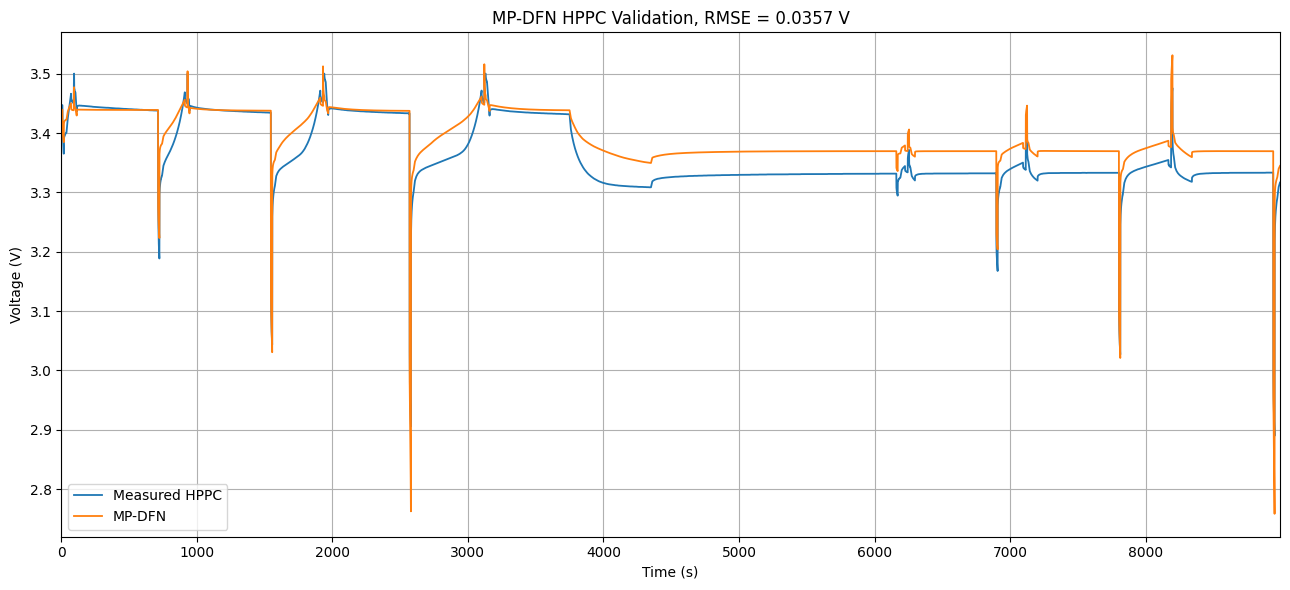

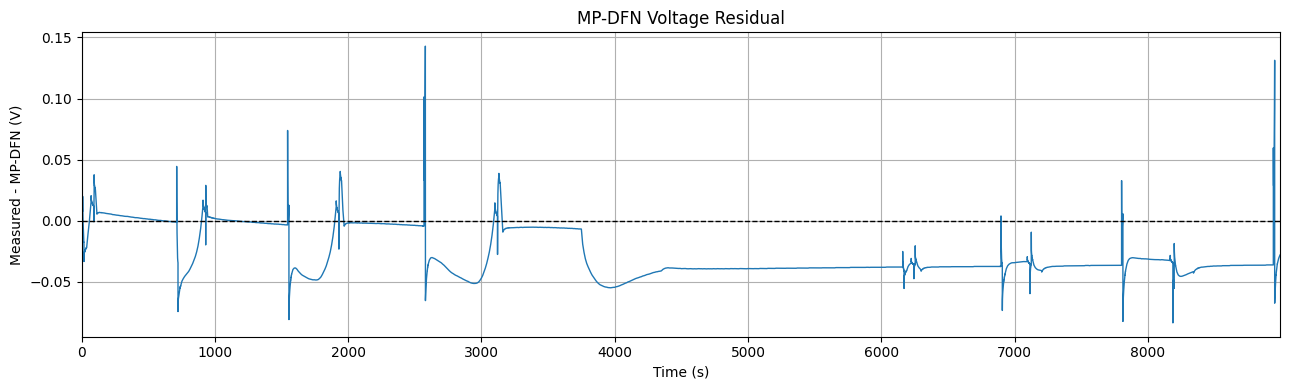

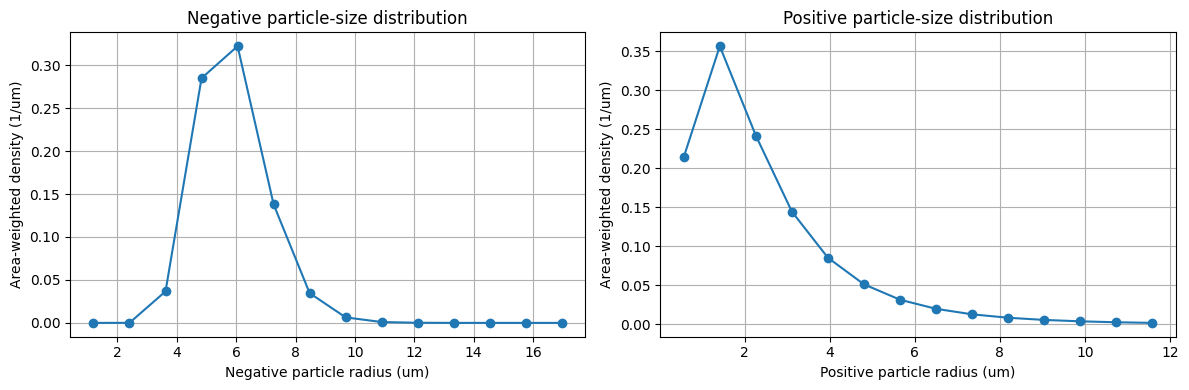

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# USER SETTINGS
# =====================================================

hppc_filename = "HPPC_5458.mat"

t_compare = 9000.0

nominal_capacity_ah = 2.5

theta_n_init = 0.905
theta_p_init = 0.5075

# Single Jokar discharge OCP baseline
ocp_shift = 0.10

negative_thickness = 129e-6
positive_thickness = 171e-6
positive_active_fraction = 0.55

# Mean positive particle radius
positive_radius_mean = 2.5e-6

# Positive PSD standard deviation
# 0.45 means SD = 45% of the mean radius
positive_radius_sd_fraction = 0.8

# Positive PSD limits
positive_radius_min = 0.15e-6
positive_radius_max = 12e-6

# Negative PSD width.
# The mean comes from Prada2013.
negative_radius_sd_fraction = 0.20

positive_diffusivity = 1.0e-13

positive_kinetic_multiplier = 30.0
negative_kinetic_multiplier = 30.0

electrolyte_conductivity_multiplier = 1.6
electrolyte_diffusivity_multiplier = 1.0

contact_resistance = 0.0

model_temperature_kelvin = 296.62

rest_current_threshold = 0.05
discharge_pulse_threshold = 5.0
charge_pulse_threshold = 1.0

# Particle-size discretization.
# Increase R_n and R_p after the model runs successfully.
particle_size_bins = 14

# =====================================================
# JOKAR POSITIVE-ELECTRODE OCP
# =====================================================

aa = 0.5

raw_cathode_axis = np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
])

cath_soc = (
    (1.0 - aa)
    + aa * (1.0 - raw_cathode_axis)
)

cath_ocv = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

cath_ocv = cath_ocv + ocp_shift

# Sort and remove nearly duplicated stoichiometry values
ocp_order = np.argsort(
    cath_soc,
    kind="stable"
)

cath_soc = cath_soc[ocp_order]
cath_ocv = cath_ocv[ocp_order]

ocp_keep = np.concatenate((
    [True],
    np.diff(cath_soc) > 1e-6
))

cath_soc = cath_soc[ocp_keep]
cath_ocv = cath_ocv[ocp_keep]

# Extend to [0, 1] with constant endpoint extension
sto_grid = np.linspace(
    0.0,
    1.0,
    1000
)

ocv_grid = np.interp(
    sto_grid,
    cath_soc,
    cath_ocv,
    left=cath_ocv[0],
    right=cath_ocv[-1]
)

def custom_positive_ocp(sto):
    return pybamm.Interpolant(
        sto_grid,
        ocv_grid,
        sto,
        interpolator="linear"
    )

# =====================================================
# LOAD AND CLEAN HPPC DATA
# =====================================================

hppc_data = loadmat(
    hppc_filename,
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(
    meas.Time,
    dtype=float
).reshape(-1)

current_raw = np.asarray(
    meas.Current,
    dtype=float
).reshape(-1)

voltage_raw = np.asarray(
    meas.Voltage,
    dtype=float
).reshape(-1)

number_raw = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:number_raw]
current_raw = current_raw[:number_raw]
voltage_raw = voltage_raw[:number_raw]

finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

time_raw = (
    time_raw
    - time_raw[0]
)

duration_mask = (
    (time_raw >= 0.0)
    & (time_raw <= t_compare)
)

time_raw = time_raw[duration_mask]
current_raw = current_raw[duration_mask]
voltage_raw = voltage_raw[duration_mask]

# Sort timestamps
time_order = np.argsort(
    time_raw,
    kind="stable"
)

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final value at every duplicated timestamp
_, reverse_unique_index = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_index = (
    len(time_sorted)
    - 1
    - reverse_unique_index
)

last_index = np.sort(
    last_index
)

time_exp = time_sorted[last_index]
current_measured = current_sorted[last_index]
voltage_exp = voltage_sorted[last_index]

# Final strict-increase protection
strict_mask = np.concatenate((
    [True],
    np.diff(time_exp) > 0.0
))

time_exp = time_exp[strict_mask]
current_measured = current_measured[strict_mask]
voltage_exp = voltage_exp[strict_mask]

if len(time_exp) < 2:
    raise ValueError(
        "Fewer than two unique HPPC timestamps remain."
    )

if not np.all(np.diff(time_exp) > 0.0):
    raise ValueError(
        "HPPC time vector is not strictly increasing."
    )

# Experimental sign is opposite to PyBaMM convention
current_pybamm = (
    -current_measured
)

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

print("Clean HPPC samples :", len(time_exp))
print("HPPC duration (s)  :", time_exp[-1])
print(
    "Strict increase    :",
    bool(np.all(np.diff(time_exp) > 0.0))
)
print(
    "Measured current   :",
    current_measured.min(),
    "to",
    current_measured.max(),
    "A"
)
print(
    "PyBaMM current     :",
    current_pybamm.min(),
    "to",
    current_pybamm.max(),
    "A"
)

# =====================================================
# BASE PRADA2013 PARAMETER SET
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

negative_radius_mean = params[
    "Negative particle radius [m]"
]

# Store original functions before overriding
original_positive_j0 = params[
    "Positive electrode exchange-current density [A.m-2]"
]

original_negative_j0 = params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_electrolyte_conductivity = params[
    "Electrolyte conductivity [S.m-1]"
]

original_electrolyte_diffusivity = params[
    "Electrolyte diffusivity [m2.s-1]"
]

# =====================================================
# CALIBRATED KINETIC FUNCTIONS
# =====================================================

def scaled_positive_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        positive_kinetic_multiplier
        * original_positive_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

def scaled_negative_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        negative_kinetic_multiplier
        * original_negative_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

# =====================================================
# CALIBRATED ELECTROLYTE FUNCTIONS
# =====================================================

def scaled_electrolyte_conductivity(
    c_e,
    temperature
):
    return (
        electrolyte_conductivity_multiplier
        * original_electrolyte_conductivity(
            c_e,
            temperature
        )
    )

def scaled_electrolyte_diffusivity(
    c_e,
    temperature
):
    return (
        electrolyte_diffusivity_multiplier
        * original_electrolyte_diffusivity(
            c_e,
            temperature
        )
    )

# =====================================================
# APPLY BASE CALIBRATED PARAMETERS
# =====================================================

params.update({
    "Nominal cell capacity [A.h]":
        nominal_capacity_ah,

    "Initial temperature [K]":
        model_temperature_kelvin,

    "Ambient temperature [K]":
        model_temperature_kelvin,

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        negative_thickness,

    "Positive electrode thickness [m]":
        positive_thickness,

    "Positive electrode active material volume fraction":
        positive_active_fraction,

    "Positive particle radius [m]":
        positive_radius_mean,

    "Positive electrode diffusivity [m2.s-1]":
        positive_diffusivity,

    "Positive electrode exchange-current density [A.m-2]":
        scaled_positive_exchange_current_density,

    "Negative electrode exchange-current density [A.m-2]":
        scaled_negative_exchange_current_density,

    "Electrolyte conductivity [S.m-1]":
        scaled_electrolyte_conductivity,

    "Electrolyte diffusivity [m2.s-1]":
        scaled_electrolyte_diffusivity,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        contact_resistance
})

# =====================================================
# ADD DEFAULT LOGNORMAL SIZE-DISTRIBUTION PARAMETERS
# =====================================================

if not hasattr(
    pybamm,
    "get_size_distribution_parameters"
):
    raise AttributeError(
        "This PyBaMM version does not provide "
        "get_size_distribution_parameters(). "
        "Upgrade PyBaMM to a version supporting MP-DFN."
    )

params = pybamm.get_size_distribution_parameters(
    params
)

# =====================================================
# CUSTOM PARTICLE-SIZE DISTRIBUTIONS
# =====================================================

positive_radius_sd = (
    positive_radius_sd_fraction
    * positive_radius_mean
)

negative_radius_sd = (
    negative_radius_sd_fraction
    * negative_radius_mean
)

negative_radius_min = max(
    0.10 * negative_radius_mean,
    1e-9
)

negative_radius_max = (
    3.0 * negative_radius_mean
)

# Area-weighted lognormal distributions.
# Each function must accept only particle radius R.
def positive_area_weighted_psd(radius):
    return pybamm.lognormal(
        radius,
        positive_radius_mean,
        positive_radius_sd
    )

def negative_area_weighted_psd(radius):
    return pybamm.lognormal(
        radius,
        negative_radius_mean,
        negative_radius_sd
    )

params.update({
    "Positive minimum particle radius [m]":
        positive_radius_min,

    "Positive maximum particle radius [m]":
        positive_radius_max,

    "Positive area-weighted particle-size distribution [m-1]":
        positive_area_weighted_psd,

    "Negative minimum particle radius [m]":
        negative_radius_min,

    "Negative maximum particle radius [m]":
        negative_radius_max,

    "Negative area-weighted particle-size distribution [m-1]":
        negative_area_weighted_psd
})

print()
print("================================")
print("MP-DFN PARTICLE DISTRIBUTIONS")
print("================================")
print(
    "Positive mean radius (m) :",
    positive_radius_mean
)
print(
    "Positive radius SD (m)   :",
    positive_radius_sd
)
print(
    "Positive radius limits   :",
    positive_radius_min,
    "to",
    positive_radius_max
)
print(
    "Negative mean radius (m) :",
    negative_radius_mean
)
print(
    "Negative radius SD (m)   :",
    negative_radius_sd
)
print(
    "Negative radius limits   :",
    negative_radius_min,
    "to",
    negative_radius_max
)

# =====================================================
# BUILD MP-DFN MODEL
# =====================================================

model = pybamm.lithium_ion.DFN(
    options={
        "particle size": "distribution",
        "contact resistance": "true",
        "thermal": "isothermal"
    },
    name="Calibrated MP-DFN"
)

# Keep mesh small for the first run.
# R_n and R_p control the number of particle-size bins.
var_pts = {
    "x_n": 12,
    "x_s": 8,
    "x_p": 12,
    "r_n": 10,
    "r_p": 10,
    "R_n": particle_size_bins,
    "R_p": particle_size_bins
}

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver,
    var_pts=var_pts
)

# =====================================================
# RUN MP-DFN
# =====================================================

solution = simulation.solve(
    t_eval=time_exp
)

time_model = np.asarray(
    solution["Time [s]"].entries,
    dtype=float
).reshape(-1)

voltage_model = np.asarray(
    solution["Terminal voltage [V]"].entries,
    dtype=float
).reshape(-1)

if len(time_model) < 2:
    raise RuntimeError(
        "MP-DFN returned fewer than two time points."
    )

# =====================================================
# VALID COMPARISON WINDOW
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1]),
    t_compare
)

valid_mask = (
    time_exp
    <= t_valid_end
)

time_valid = time_exp[
    valid_mask
]

current_valid = current_pybamm[
    valid_mask
]

voltage_measured_valid = voltage_exp[
    valid_mask
]

voltage_simulated_valid = np.interp(
    time_valid,
    time_model,
    voltage_model
)

voltage_error = (
    voltage_measured_valid
    - voltage_simulated_valid
)

# =====================================================
# METRICS
# =====================================================

overall_rmse = float(
    np.sqrt(
        np.mean(
            voltage_error ** 2
        )
    )
)

overall_mae = float(
    np.mean(
        np.abs(
            voltage_error
        )
    )
)

maximum_error = float(
    np.max(
        np.abs(
            voltage_error
        )
    )
)

overall_bias = float(
    np.mean(
        voltage_error
    )
)

rest_mask = (
    np.abs(current_valid)
    < rest_current_threshold
)

discharge_mask = (
    current_valid
    > discharge_pulse_threshold
)

charge_mask = (
    current_valid
    < -charge_pulse_threshold
)

intermediate_mask = (
    ~rest_mask
    & ~discharge_mask
    & ~charge_mask
)

def masked_rmse(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.sqrt(
            np.mean(
                voltage_error[mask] ** 2
            )
        )
    )

def masked_bias(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.mean(
            voltage_error[mask]
        )
    )

rest_rmse = masked_rmse(
    rest_mask
)

rest_bias = masked_bias(
    rest_mask
)

discharge_rmse = masked_rmse(
    discharge_mask
)

discharge_bias = masked_bias(
    discharge_mask
)

charge_rmse = masked_rmse(
    charge_mask
)

charge_bias = masked_bias(
    charge_mask
)

intermediate_rmse = masked_rmse(
    intermediate_mask
)

intermediate_bias = masked_bias(
    intermediate_mask
)

# =====================================================
# THROUGHPUT
# =====================================================

integrator = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

net_discharge_ah = float(
    integrator(
        current_valid,
        time_valid
    ) / 3600.0
)

absolute_throughput_ah = float(
    integrator(
        np.abs(current_valid),
        time_valid
    ) / 3600.0
)

# =====================================================
# PRINT RESULTS
# =====================================================

print()
print("================================")
print("MP-DFN HPPC VALIDATION")
print("================================")
print(
    "Compared duration (s)    :",
    t_valid_end
)
print(
    "Compared samples         :",
    len(time_valid)
)
print(
    "Net discharge (Ah)       :",
    net_discharge_ah
)
print(
    "Absolute throughput (Ah) :",
    absolute_throughput_ah
)
print()
print(
    "Overall RMSE (V)         :",
    overall_rmse
)
print(
    "Overall MAE (V)          :",
    overall_mae
)
print(
    "Maximum error (V)        :",
    maximum_error
)
print(
    "Overall bias (V)         :",
    overall_bias
)
print()
print(
    "Rest RMSE / bias (V)     :",
    rest_rmse,
    "/",
    rest_bias
)
print(
    "Discharge RMSE/bias (V)  :",
    discharge_rmse,
    "/",
    discharge_bias
)
print(
    "Charge RMSE / bias (V)   :",
    charge_rmse,
    "/",
    charge_bias
)
print(
    "Intermediate RMSE/bias   :",
    intermediate_rmse,
    "/",
    intermediate_bias
)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(figsize=(13, 6))

plt.plot(
    time_valid,
    voltage_measured_valid,
    linewidth=1.3,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.3,
    label="MP-DFN"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")

plt.title(
    f"MP-DFN HPPC Validation, "
    f"RMSE = {overall_rmse:.4f} V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(figsize=(13, 4))

plt.plot(
    time_valid,
    voltage_error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel("Time (s)")
plt.ylabel("Measured - MP-DFN (V)")
plt.title("MP-DFN Voltage Residual")

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# PLOT DISCRETIZED PARTICLE-SIZE DISTRIBUTIONS
# =====================================================

try:
    positive_sizes = solution[
        "Positive particle sizes [m]"
    ].entries[:, 0, 0]

    negative_sizes = solution[
        "Negative particle sizes [m]"
    ].entries[:, 0, 0]

    positive_psd = solution[
        "X-averaged positive area-weighted "
        "particle-size distribution [m-1]"
    ].entries[:, 0]

    negative_psd = solution[
        "X-averaged negative area-weighted "
        "particle-size distribution [m-1]"
    ].entries[:, 0]

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    axes[0].plot(
        negative_sizes * 1e6,
        negative_psd * 1e-6,
        marker="o"
    )

    axes[0].set_xlabel(
        "Negative particle radius (um)"
    )

    axes[0].set_ylabel(
        "Area-weighted density (1/um)"
    )

    axes[0].set_title(
        "Negative particle-size distribution"
    )

    axes[0].grid(True)

    axes[1].plot(
        positive_sizes * 1e6,
        positive_psd * 1e-6,
        marker="o"
    )

    axes[1].set_xlabel(
        "Positive particle radius (um)"
    )

    axes[1].set_ylabel(
        "Area-weighted density (1/um)"
    )

    axes[1].set_title(
        "Positive particle-size distribution"
    )

    axes[1].grid(True)

    figure.tight_layout()
    plt.show()

except Exception as distribution_error:

    print()
    print(
        "Particle-size distribution plot skipped:"
    )
    print(distribution_error)

In [ ]:
# LFP SOC curve updated as per - https://www.researchgate.net/publication/334119055_Combined_CNN-LSTM_Network_for_State-of-Charge_Estimation_of_Lithium-Ion_Batteries

In [2]:
import numpy as np
import pybamm

# =====================================================
# DIGITIZED LFP OCV VS SOC
# SOC range: 0 to 1
# =====================================================

lfp_soc = np.array([
    0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
    0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19,
    0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29,
    0.30, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39,
    0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49,
    0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59,
    0.60, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69,
    0.70, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79,
    0.80, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89,
    0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
    1.00
])

lfp_ocv = np.array([
    2.318000, 2.772409, 2.906339, 2.983935, 3.038800,
    3.088807, 3.124545, 3.155909, 3.187709, 3.204545,
    3.213636, 3.213636, 3.214800, 3.222727, 3.222727,
    3.226563, 3.231818, 3.239990, 3.240909, 3.250000,
    3.250000, 3.257097, 3.259091, 3.260010, 3.268182,
    3.268182, 3.271745, 3.277273, 3.277273, 3.277306,
    3.286364, 3.286364, 3.286364, 3.286364, 3.295455,
    3.295455, 3.295455, 3.300000, 3.304545, 3.304545,
    3.304545, 3.304545, 3.304545, 3.304545, 3.304545,
    3.304545, 3.309091, 3.309091, 3.313636, 3.313636,
    3.313636, 3.313636, 3.313636, 3.313636, 3.313636,
    3.313636, 3.313636, 3.313636, 3.313636, 3.313636,
    3.313636, 3.313636, 3.313636, 3.313636, 3.313636,
    3.313636, 3.313636, 3.313636, 3.321127, 3.322727,
    3.322727, 3.322727, 3.329527, 3.331818, 3.336364,
    3.340909, 3.340909, 3.340909, 3.345582, 3.350000,
    3.350000, 3.350000, 3.350000, 3.350000, 3.350000,
    3.350000, 3.350000, 3.350000, 3.350000, 3.350000,
    3.350000, 3.354512, 3.359091, 3.359091, 3.359091,
    3.368182, 3.378327, 3.393984, 3.423756, 3.484712,
    3.581818
])
